# VERSION WITH PROBABILITY THRESHOLD 0.8

# ML Predictor Comparison: Baseline vs Probability Filter

This notebook compares the original predictor in `ML_predictor.py` with the probability-aware predictor in `ML_predictor_probability.py`.

Both strategies use the same data, walk-forward training window, feature grid, signal thresholds, backtester, and execution settings. The probability strategy uses `probability_threshold=0.80`, so it assigns a non-zero weight only when its most likely class has probability strictly above 80%.

The structure follows `test_PCA_scaler_comparison.ipynb`: parallel grid execution, saved case artifacts, performance leaderboards, matched-grid deltas, heatmaps, prediction agreement, diagnostics, and winner equity curves.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import time
import json
import itertools
import warnings

from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"
for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from ML_predictor import MLPredictorStrategy as BaselineStrategy
from ML_predictor_probability import MLPredictorStrategy as ProbabilityStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")

Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## 2. Grid Specification

The requested grid contains 72 runs: two strategies × nine `n_features` values × four `signal_threshold` values. `training_years` is fixed at 10.

In [ ]:
SYMBOL = "ECH"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

STRATEGIES = {
    "baseline": BaselineStrategy,
    "probability_80pct": ProbabilityStrategy,
}
TRAINING_YEARS = 10
N_FEATURES_GRID = list(range(1, 20)) \
+ list(range(20, 50, 5)) \
+ list(range(50, 100, 10)) \
+ list(range(100, 201, 20))
SIGNAL_THRESHOLD_GRID = [0.000, 0.001, 0.002, 0.003, 0.004, 0.005]
PROBABILITY_THRESHOLD = 0.80

COMMON_PARAMS = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": TRAINING_YEARS,
    "download_data": False,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

RUN_GRID = True
N_JOBS = 16
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_DIR = ml_dir / "test_probability_strategy_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

grid_cases = list(itertools.product(STRATEGIES, N_FEATURES_GRID, SIGNAL_THRESHOLD_GRID))
assert N_FEATURES_GRID == [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,\
                            25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 120, 140, 160, 180, 200]
assert SIGNAL_THRESHOLD_GRID == [0.000, 0.001, 0.002, 0.003, 0.004, 0.005]
assert len(grid_cases) == 432

print(f"Grid cases: {len(grid_cases)} ({len(grid_cases) // len(STRATEGIES)} matched points per strategy)")
print(f"Output directory: {OUTPUT_DIR}")

Grid cases: 432 (216 matched points per strategy)
Output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_probability_strategy_comparison_outputs


## 3. Helper Functions

These helpers follow the PCA comparison notebook's conventions for run IDs, performance statistics, artifact persistence, and self-contained single-case execution.

In [3]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, strategy_name: str, n_features: int, signal_threshold: float) -> str:
    return (
        f"{symbol}_strategy-{strategy_name}"
        f"_features-{n_features}"
        f"_sig-{safe_value(signal_threshold)}"
    )


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    volatility = returns.std()
    if volatility == 0 or np.isnan(volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / volatility


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside_volatility = returns[returns < 0].std()
    if downside_volatility == 0 or np.isnan(downside_volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_volatility


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(
    run_id: str,
    strategy_name: str,
    params: dict,
    stats: pd.DataFrame,
    weights: pd.DataFrame,
    predictions: pd.DataFrame,
    elapsed_seconds: float,
) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100
    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    prediction_counts = predictions["prediction"].value_counts(normalize=True).sort_index() * 100
    max_probability = predictions.get("max_probability", pd.Series(np.nan, index=predictions.index))
    passed_filter = predictions.get("passes_probability_threshold", pd.Series(True, index=predictions.index))

    return {
        "run_id": run_id,
        "strategy": strategy_name,
        "symbol": params["symbol"],
        "n_features": params["n_features"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "probability_threshold": params.get("probability_threshold", np.nan),
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "net_sortino": annualized_sortino(stats["net_returns"]),
        "win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "zero_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
        "mean_max_probability": max_probability.mean(),
        "median_max_probability": (max_probability.median() if max_probability.notna().any() else np.nan),
        "passes_probability_threshold_pct": passed_filter.mean() * 100,
        "elapsed_seconds": elapsed_seconds,
    }

In [4]:
def save_case_artifacts(run_id: str, artifacts: dict) -> None:
    run_dir = OUTPUT_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["predictions"].to_pickle(run_dir / "predictions.pkl")
    with open(run_dir / "metrics.json", "w") as file:
        json.dump(artifacts["metrics"], file, indent=2, default=str)


def run_one_case(strategy_name: str, n_features: int, signal_threshold: float) -> dict:
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    print(f"Running {run_id}")
    start = time.time()

    params = {
        **COMMON_PARAMS,
        "n_features": n_features,
        "signal_threshold": signal_threshold,
    }
    if strategy_name == "probability_80pct":
        params["probability_threshold"] = PROBABILITY_THRESHOLD

    strategy = STRATEGIES[strategy_name](params=params)
    dataset = strategy.prepare_dataset()
    prediction_output = strategy.predict(dataset, show_progress=SHOW_PROGRESS)

    if isinstance(prediction_output, pd.Series):
        predictions = prediction_output.rename("prediction").to_frame()
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] *= params["position_size"]
        predictions["max_probability"] = np.nan
        predictions["passes_probability_threshold"] = True
    else:
        predictions = prediction_output.copy()
        probability_columns = ["probability_-1", "probability_0", "probability_1"]
        predictions["max_probability"] = predictions[probability_columns].max(axis=1)
        predictions["passes_probability_threshold"] = predictions["max_probability"] > params["probability_threshold"]
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] = weights[SYMBOL].where(predictions["passes_probability_threshold"], 0)
        weights[SYMBOL] *= params["position_size"]

    prices = dataset[["Open"]].rename(columns={"Open": SYMBOL}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=ASSET_CLASS,
        initial_capital=INITIAL_CAPITAL,
        execution_delay=EXECUTION_DELAY,
    )
    stats = engine.run()
    metrics = summarize_performance(
        run_id,
        strategy_name,
        params,
        stats,
        weights,
        predictions,
        time.time() - start,
    )
    artifacts = {
        "run_id": run_id,
        "params": params,
        "weights": weights,
        "predictions": predictions,
        "prices": prices,
        "stats": stats,
        "metrics": metrics,
    }
    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)
    return artifacts

## 4. Run the Parallel Grid

This is the expensive cell. Like the PCA comparison notebook, it uses joblib's process-based `loky` backend and saves every successful run under `test_probability_strategy_comparison_outputs/`.

In [5]:
grid_artifacts = {}
grid_metrics = []
grid_errors = []


def run_one_case_safely(case):
    strategy_name, n_features, signal_threshold = case
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    try:
        artifacts = run_one_case(strategy_name, n_features, signal_threshold)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "run_id": run_id,
            "strategy": strategy_name,
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


if RUN_GRID:
    grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
        delayed(run_one_case_safely)(case)
        for case in grid_cases
    )

    for result in grid_results:
        if result["ok"]:
            grid_artifacts[result["run_id"]] = result["artifacts"]
            grid_metrics.append(result["artifacts"]["metrics"])
        else:
            grid_errors.append({key: value for key, value in result.items() if key != "ok"})

metrics_df = pd.DataFrame(grid_metrics)
errors_df = pd.DataFrame(grid_errors)

metrics_df["net_return_rank"] = metrics_df["net_return_pct"].rank(method="min", ascending=False, na_option="bottom")
metrics_df["net_sharpe_rank"] = metrics_df["net_sharpe"].rank(method="min", ascending=False, na_option="bottom")
metrics_df["net_sortino_rank"] = metrics_df["net_sortino"].rank(method="min", ascending=False, na_option="bottom")
metrics_df["performance_score"] = (
    0.50 * metrics_df["net_return_rank"]
    + 0.25 * metrics_df["net_sharpe_rank"]
    + 0.25 * metrics_df["net_sortino_rank"]
)
metrics_df["performance_rank"] = metrics_df["performance_score"].rank(method="min", ascending=True).astype(int)

if SAVE_ARTIFACTS and not metrics_df.empty:
    metrics_df.to_pickle(OUTPUT_DIR / "grid_metrics.pkl")
    metrics_df.to_csv(OUTPUT_DIR / "grid_metrics.csv", index=False)
if SAVE_ARTIFACTS and not errors_df.empty:
    errors_df.to_csv(OUTPUT_DIR / "grid_errors.csv", index=False)

display(metrics_df.sort_values(["performance_rank", "performance_score", "net_return_pct"], ascending=[True, True, False]).head(10))
display(errors_df)

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.


Running ECH_strategy-baseline_features-1_sig-0
Running ECH_strategy-baseline_features-1_sig-0p001
Running ECH_strategy-baseline_features-1_sig-0p002
Running ECH_strategy-baseline_features-1_sig-0p003
Running ECH_strategy-baseline_features-2_sig-0p002
Running ECH_strategy-baseline_features-1_sig-0p004
Running ECH_strategy-baseline_features-2_sig-0p001
Running ECH_strategy-baseline_features-1_sig-0p005
Running ECH_strategy-baseline_features-2_sig-0p003
Running ECH_strategy-baseline_features-2_sig-0
Running ECH_strategy-baseline_features-3_sig-0p001
Running ECH_strategy-baseline_features-2_sig-0p004
Running ECH_strategy-baseline_features-2_sig-0p005
Running ECH_strategy-baseline_features-3_sig-0
Running ECH_strategy-baseline_features-3_sig-0p002
Running ECH_strategy-baseline_features-3_sig-0p003
Running ECH_strategy-baseline_features-3_sig-0p004
Running ECH_strategy-baseline_features-3_sig-0p005
Running ECH_strategy-baseline_features-4_sig-0
Running ECH_strategy-baseline_features-4_sig-0p

[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:   46.7s


Running ECH_strategy-baseline_features-5_sig-0
Running ECH_strategy-baseline_features-5_sig-0p001
Running ECH_strategy-baseline_features-5_sig-0p002
Running ECH_strategy-baseline_features-5_sig-0p003
Running ECH_strategy-baseline_features-5_sig-0p004
Running ECH_strategy-baseline_features-5_sig-0p005
Running ECH_strategy-baseline_features-6_sig-0
Running ECH_strategy-baseline_features-6_sig-0p001
Running ECH_strategy-baseline_features-6_sig-0p002
Running ECH_strategy-baseline_features-6_sig-0p003


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:  1.5min


...

[Parallel(n_jobs=16)]: Done 389 tasks      | elapsed: 1292.2min


Running ECH_strategy-probability_80pct_features-120_sig-0p002
Running ECH_strategy-probability_80pct_features-120_sig-0p003
Running ECH_strategy-probability_80pct_features-120_sig-0p004
Running ECH_strategy-probability_80pct_features-120_sig-0p005
Running ECH_strategy-probability_80pct_features-140_sig-0
Running ECH_strategy-probability_80pct_features-140_sig-0p001
Running ECH_strategy-probability_80pct_features-140_sig-0p002
Running ECH_strategy-probability_80pct_features-140_sig-0p003
Running ECH_strategy-probability_80pct_features-140_sig-0p004
Running ECH_strategy-probability_80pct_features-140_sig-0p005
Running ECH_strategy-probability_80pct_features-160_sig-0
Running ECH_strategy-probability_80pct_features-160_sig-0p001
Running ECH_strategy-probability_80pct_features-160_sig-0p002
Running ECH_strategy-probability_80pct_features-160_sig-0p003
Running ECH_strategy-probability_80pct_features-160_sig-0p004
Running ECH_strategy-probability_80pct_features-160_sig-0p005
Running ECH_stra

[Parallel(n_jobs=16)]: Done 432 out of 432 | elapsed: 1353.7min finished


,run_id,strategy,symbol,n_features,signal_threshold,training_years,probability_threshold,gross_return_pct,net_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,net_sharpe,net_sortino,win_rate_pct,loss_rate_pct,zero_rate_pct,active_days_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,average_daily_turnover,total_fees_paid,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,mean_max_probability,median_max_probability,passes_probability_threshold_pct,elapsed_seconds,net_return_rank,net_sharpe_rank,net_sortino_rank,performance_score,performance_rank
93,ECH_strategy-baseline_features-16_sig-0p003,baseline,ECH,16,0.003,10,NaN,60.582496,54.762360,65.173061,-10.410700,-11.309419,2.054118,3.229398,53.815261,42.168675,4.016064,98.8,54.8,44.0,1.2,0.988,0.832,58201.361100,44.0,1.2,54.8,NaN,NaN,100.0,306.087349,1.0,2.0,9.0,3.25,1
87,ECH_strategy-baseline_features-15_sig-0p003,baseline,ECH,15,0.003,10,NaN,59.079112,52.807464,65.173061,-12.365597,-10.294609,1.997513,2.979905,55.020080,40.963855,4.016064,98.8,56.4,42.4,1.2,0.988,0.888,62716.483833,42.4,1.2,56.4,NaN,NaN,100.0,369.737251,2.0,3.0,10.0,4.25,2
154,ECH_strategy-baseline_features-50_sig-0p004,baseline,ECH,50,0.004,10,NaN,49.444301,43.678575,65.173061,-21.494485,-12.631626,1.763492,2.710408,48.995984,41.767068,9.236948,92.8,50.4,42.4,7.2,0.928,0.872,57657.256659,42.4,7.2,50.4,NaN,NaN,100.0,289.910442,3.0,6.0,11.0,5.75,3
142,ECH_strategy-baseline_features-40_sig-0p004,baseline,ECH,40,0.004,10,NaN,48.714014,42.767232,65.173061,-22.405828,-8.534851,1.698958,2.556664,52.208835,39.357430,8.433735,94.0,45.6,48.4,6.0,0.940,0.848,59467.821796,48.4,6.0,45.6,NaN,NaN,100.0,299.809875,4.0,9.0,13.0,7.50,4
68,ECH_strategy-baseline_features-12_sig-0p002,baseline,ECH,12,0.002,10,NaN,43.881399,38.511457,65.173061,-26.661604,-13.136906,1.542558,2.228133,54.618474,42.570281,2.811245,100.0,65.2,34.8,0.0,1.000,0.824,53699.423695,34.8,0.0,65.2,NaN,NaN,100.0,220.936819,5.0,11.0,16.0,9.25,5
161,ECH_strategy-baseline_features-60_sig-0p005,baseline,ECH,60,0.005,10,NaN,40.888689,36.189576,65.173061,-28.983485,-12.299951,1.788267,2.289067,32.931727,25.702811,41.365462,58.4,36.4,22.0,41.6,0.584,0.708,46991.138666,22.0,41.6,36.4,NaN,NaN,100.0,319.606058,9.0,5.0,14.0,9.25,5
110,ECH_strategy-baseline_features-19_sig-0p002,baseline,ECH,19,0.002,10,NaN,42.544220,37.201157,65.173061,-27.971903,-10.343428,1.502055,2.224962,53.012048,44.176707,2.811245,100.0,61.6,38.4,0.0,1.000,0.848,53430.626888,38.4,0.0,61.6,NaN,NaN,100.0,277.657673,6.0,13.0,17.0,10.50,7
98,ECH_strategy-baseline_features-17_sig-0p002,baseline,ECH,17,0.002,10,NaN,42.355933,36.957403,65.173061,-28.215658,-11.247092,1.493273,2.093955,56.626506,40.562249,2.811245,100.0,62.8,37.2,0.0,1.000,0.864,53985.306032,37.2,0.0,62.8,NaN,NaN,100.0,313.378445,7.0,14.0,20.0,12.00,8
130,ECH_strategy-baseline_features-30_sig-0p004,baseline,ECH,30,0.004,10,NaN,42.105723,36.305079,65.173061,-28.867982,-10.436483,1.542022,2.061735,51.004016,38.955823,10.040161,92.0,48.0,44.0,8.0,0.920,0.880,58006.438608,44.0,8.0,48.0,NaN,NaN,100.0,350.729088,8.0,12.0,21.0,12.25,9
75,ECH_strategy-baseline_features-13_sig-0p003,baseline,ECH,13,0.003,10,NaN,40.861229,35.783310,65.173061,-29.389750,-22.435152,1.456182,2.231449,53.012048,44.176707,2.811245,100.0,58.4,41.6,0.0,1.000,0.864,50779.191314,41.6,0.0,58.4,NaN,NaN,100.0,234.476810,10.0,16.0,15.0,12.75,10


""


## 5. Performance Leaderboards



Use performance rank to identify the best performer. Its score is `0.50 × net-return rank + 0.25 × net-Sharpe rank + 0.25 × net-Sortino rank`; lower scores and ranks are better. Then inspect drawdown, fees, activity, and turnover as secondary diagnostics. The probability-specific confidence columns are `NaN` for the baseline by design.

In [6]:
leaderboard_cols = [
    "performance_rank", "performance_score", "run_id", "strategy",
    "n_features", "signal_threshold", "probability_threshold",
    "net_return_rank", "net_sharpe_rank", "net_sortino_rank",
    "net_return_pct", "gross_return_pct", "benchmark_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "win_rate_pct", "loss_rate_pct", "zero_rate_pct",
    "long_days_pct", "short_days_pct", "flat_days_pct", "average_abs_exposure",
    "prediction_minus1_pct", "prediction_0_pct", "prediction_plus1_pct",
    "active_days_pct", "average_daily_turnover", "mean_max_probability",
    "passes_probability_threshold_pct", "elapsed_seconds",
]

print("Best performers by PERFORMANCE RANK")
display(metrics_df[leaderboard_cols].sort_values(["performance_rank", "performance_score", "net_return_pct"], ascending=[True, True, False]).head(15).round(3))
print("\nHighest NET RETURN (50% score component)")
display(metrics_df[leaderboard_cols].sort_values("net_return_pct", ascending=False).head(15).round(3))
print("\nHighest NET SHARPE RATIO (25% score component)")
display(metrics_df[leaderboard_cols].sort_values("net_sharpe", ascending=False).head(15).round(3))
print("\nSmallest MAX DRAWDOWN (secondary diagnostic)")
display(metrics_df[leaderboard_cols].sort_values("max_drawdown_pct", ascending=False).head(15).round(3))

best_by_strategy = metrics_df.sort_values(["performance_rank", "performance_score", "net_return_pct"], ascending=[True, True, False]).groupby("strategy").head(1)
print("\nBest performance-ranked run from each strategy")
display(best_by_strategy[leaderboard_cols].round(3))

Best performers by PERFORMANCE RANK


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,3.25,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,2.0,9.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,306.087
87,2,4.25,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,2.0,3.0,10.0,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,369.737
154,3,5.75,ECH_strategy-baseline_features-50_sig-0p004,baseline,50,0.004,NaN,3.0,6.0,11.0,43.679,49.444,65.173,-21.494,1.763,2.710,-12.632,57657.257,48.996,41.767,9.237,50.4,42.4,7.2,0.928,42.4,7.2,50.4,92.8,0.872,NaN,100.0,289.910
142,4,7.50,ECH_strategy-baseline_features-40_sig-0p004,baseline,40,0.004,NaN,4.0,9.0,13.0,42.767,48.714,65.173,-22.406,1.699,2.557,-8.535,59467.822,52.209,39.357,8.434,45.6,48.4,6.0,0.940,48.4,6.0,45.6,94.0,0.848,NaN,100.0,299.810
68,5,9.25,ECH_strategy-baseline_features-12_sig-0p002,baseline,12,0.002,NaN,5.0,11.0,16.0,38.511,43.881,65.173,-26.662,1.543,2.228,-13.137,53699.424,54.618,42.570,2.811,65.2,34.8,0.0,1.000,34.8,0.0,65.2,100.0,0.824,NaN,100.0,220.937
161,5,9.25,ECH_strategy-baseline_features-60_sig-0p005,baseline,60,0.005,NaN,9.0,5.0,14.0,36.190,40.889,65.173,-28.983,1.788,2.289,-12.300,46991.139,32.932,25.703,41.365,36.4,22.0,41.6,0.584,22.0,41.6,36.4,58.4,0.708,NaN,100.0,319.606
110,7,10.50,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,6.0,13.0,17.0,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,277.658
98,8,12.00,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,7.0,14.0,20.0,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,313.378
130,9,12.25,ECH_strategy-baseline_features-30_sig-0p004,baseline,30,0.004,NaN,8.0,12.0,21.0,36.305,42.106,65.173,-28.868,1.542,2.062,-10.436,58006.439,51.004,38.956,10.040,48.0,44.0,8.0,0.920,44.0,8.0,48.0,92.0,0.880,NaN,100.0,350.729
75,10,12.75,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,10.0,16.0,15.0,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,234.477



Highest NET RETURN (50% score component)


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,3.25,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,2.0,9.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,306.087
87,2,4.25,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,2.0,3.0,10.0,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,369.737
154,3,5.75,ECH_strategy-baseline_features-50_sig-0p004,baseline,50,0.004,NaN,3.0,6.0,11.0,43.679,49.444,65.173,-21.494,1.763,2.710,-12.632,57657.257,48.996,41.767,9.237,50.4,42.4,7.2,0.928,42.4,7.2,50.4,92.8,0.872,NaN,100.0,289.910
142,4,7.50,ECH_strategy-baseline_features-40_sig-0p004,baseline,40,0.004,NaN,4.0,9.0,13.0,42.767,48.714,65.173,-22.406,1.699,2.557,-8.535,59467.822,52.209,39.357,8.434,45.6,48.4,6.0,0.940,48.4,6.0,45.6,94.0,0.848,NaN,100.0,299.810
68,5,9.25,ECH_strategy-baseline_features-12_sig-0p002,baseline,12,0.002,NaN,5.0,11.0,16.0,38.511,43.881,65.173,-26.662,1.543,2.228,-13.137,53699.424,54.618,42.570,2.811,65.2,34.8,0.0,1.000,34.8,0.0,65.2,100.0,0.824,NaN,100.0,220.937
110,7,10.50,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,6.0,13.0,17.0,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,277.658
98,8,12.00,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,7.0,14.0,20.0,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,313.378
130,9,12.25,ECH_strategy-baseline_features-30_sig-0p004,baseline,30,0.004,NaN,8.0,12.0,21.0,36.305,42.106,65.173,-28.868,1.542,2.062,-10.436,58006.439,51.004,38.956,10.040,48.0,44.0,8.0,0.920,44.0,8.0,48.0,92.0,0.880,NaN,100.0,350.729
161,5,9.25,ECH_strategy-baseline_features-60_sig-0p005,baseline,60,0.005,NaN,9.0,5.0,14.0,36.190,40.889,65.173,-28.983,1.788,2.289,-12.300,46991.139,32.932,25.703,41.365,36.4,22.0,41.6,0.584,22.0,41.6,36.4,58.4,0.708,NaN,100.0,319.606
75,10,12.75,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,10.0,16.0,15.0,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,234.477



Highest NET SHARPE RATIO (25% score component)


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
427,36,41.00,ECH_strategy-probability_80pct_features-200_si...,probability_80pct,200,0.001,0.8,81.0,1.0,1.0,11.958,12.371,65.173,-53.215,2.180,321.115,-0.026,4128.766,3.213,0.000,96.787,1.6,2.0,96.4,0.036,49.6,0.8,49.6,3.6,0.072,0.576,3.6,1567.079
93,1,3.25,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,2.0,9.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,306.087
87,2,4.25,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,2.0,3.0,10.0,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,369.737
385,45,52.75,ECH_strategy-probability_80pct_features-80_sig...,probability_80pct,80,0.001,0.8,100.0,4.0,7.0,8.892,9.325,65.173,-56.281,1.971,8.801,-0.269,4332.990,3.213,0.402,96.386,2.0,1.6,96.4,0.036,48.4,0.0,51.6,3.6,0.072,0.576,3.6,612.127
161,5,9.25,ECH_strategy-baseline_features-60_sig-0p005,baseline,60,0.005,NaN,9.0,5.0,14.0,36.190,40.889,65.173,-28.983,1.788,2.289,-12.300,46991.139,32.932,25.703,41.365,36.4,22.0,41.6,0.584,22.0,41.6,36.4,58.4,0.708,NaN,100.0,319.606
154,3,5.75,ECH_strategy-baseline_features-50_sig-0p004,baseline,50,0.004,NaN,3.0,6.0,11.0,43.679,49.444,65.173,-21.494,1.763,2.710,-12.632,57657.257,48.996,41.767,9.237,50.4,42.4,7.2,0.928,42.4,7.2,50.4,92.8,0.872,NaN,100.0,289.910
337,64,67.25,ECH_strategy-probability_80pct_features-25_sig...,probability_80pct,25,0.001,0.8,129.0,7.0,4.0,4.660,4.845,65.173,-60.513,1.761,143.147,-0.025,1847.969,1.606,0.000,98.394,0.8,0.8,98.4,0.016,43.6,0.0,56.4,1.6,0.032,0.555,1.6,1829.929
342,56,63.00,ECH_strategy-probability_80pct_features-30_sig-0,probability_80pct,30,0.000,0.8,118.0,8.0,8.0,6.180,6.411,65.173,-58.993,1.712,5.221,-0.248,2310.872,1.606,0.402,97.992,0.8,1.2,98.0,0.020,50.4,0.0,49.6,2.0,0.040,0.587,2.0,3813.602
142,4,7.50,ECH_strategy-baseline_features-40_sig-0p004,baseline,40,0.004,NaN,4.0,9.0,13.0,42.767,48.714,65.173,-22.406,1.699,2.557,-8.535,59467.822,52.209,39.357,8.434,45.6,48.4,6.0,0.940,48.4,6.0,45.6,94.0,0.848,NaN,100.0,299.810
143,11,13.25,ECH_strategy-baseline_features-40_sig-0p005,baseline,40,0.005,NaN,12.0,10.0,19.0,33.414,39.070,65.173,-31.759,1.688,2.123,-9.855,56557.819,33.333,25.703,40.964,34.4,25.6,40.0,0.600,25.6,40.0,34.4,60.0,0.836,NaN,100.0,275.758



Smallest MAX DRAWDOWN (secondary diagnostic)


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
216,190,229.25,ECH_strategy-probability_80pct_features-1_sig-0,probability_80pct,1,0.000,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,45.6,0.0,54.4,0.0,0.0,0.543,0.0,145.836
277,190,229.25,ECH_strategy-probability_80pct_features-11_sig...,probability_80pct,11,0.001,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,28.0,0.0,72.0,0.0,0.0,0.514,0.0,136.342
287,190,229.25,ECH_strategy-probability_80pct_features-12_sig...,probability_80pct,12,0.005,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,34.0,5.6,60.4,0.0,0.0,0.390,0.0,194.256
286,190,229.25,ECH_strategy-probability_80pct_features-12_sig...,probability_80pct,12,0.004,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,42.0,4.8,53.2,0.0,0.0,0.413,0.0,207.660
285,190,229.25,ECH_strategy-probability_80pct_features-12_sig...,probability_80pct,12,0.003,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,43.2,0.4,56.4,0.0,0.0,0.445,0.0,247.678
284,190,229.25,ECH_strategy-probability_80pct_features-12_sig...,probability_80pct,12,0.002,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,34.8,0.0,65.2,0.0,0.0,0.489,0.0,252.481
282,190,229.25,ECH_strategy-probability_80pct_features-12_sig-0,probability_80pct,12,0.000,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,34.4,0.0,65.6,0.0,0.0,0.543,0.0,228.247
281,190,229.25,ECH_strategy-probability_80pct_features-11_sig...,probability_80pct,11,0.005,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,32.0,2.0,66.0,0.0,0.0,0.388,0.0,133.897
280,190,229.25,ECH_strategy-probability_80pct_features-11_sig...,probability_80pct,11,0.004,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,40.4,1.2,58.4,0.0,0.0,0.409,0.0,160.541
279,190,229.25,ECH_strategy-probability_80pct_features-11_sig...,probability_80pct,11,0.003,0.8,190.0,272.0,265.0,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,37.2,0.0,62.8,0.0,0.0,0.439,0.0,185.902



Best performance-ranked run from each strategy


,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
93,1,3.25,ECH_strategy-baseline_features-16_sig-0p003,baseline,16,0.003,NaN,1.0,2.0,9.0,54.762,60.582,65.173,-10.411,2.054,3.229,-11.309,58201.361,53.815,42.169,4.016,54.8,44.0,1.2,0.988,44.0,1.2,54.8,98.8,0.832,NaN,100.0,306.087
427,36,41.00,ECH_strategy-probability_80pct_features-200_si...,probability_80pct,200,0.001,0.8,81.0,1.0,1.0,11.958,12.371,65.173,-53.215,2.180,321.115,-0.026,4128.766,3.213,0.000,96.787,1.6,2.0,96.4,0.036,49.6,0.8,49.6,3.6,0.072,0.576,3.6,1567.079


## 6. Matched Probability-minus-Baseline Deltas


Each row compares identical `(n_features, signal_threshold)` settings. Deltas are `probability_80pct - baseline`; positive values favor the probability strategy for returns and risk-adjusted metrics, while fee, turnover, and drawdown deltas need to be interpreted in context.

In [7]:
compare_metrics = [
    "net_return_pct", "gross_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "active_days_pct", "flat_days_pct", "average_abs_exposure", "average_daily_turnover",
]

wide = metrics_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="strategy",
    values=compare_metrics,
)

delta_records = []
for metric in compare_metrics:
    probability_key = (metric, "probability_80pct")
    baseline_key = (metric, "baseline")
    if probability_key not in wide.columns or baseline_key not in wide.columns:
        continue
    for (n_features, signal_threshold), value in (wide[probability_key] - wide[baseline_key]).items():
        delta_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "metric": metric,
            "probability_minus_baseline": value,
        })

deltas_df = pd.DataFrame(delta_records)
matched_deltas = deltas_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="metric",
    values="probability_minus_baseline",
)
display(matched_deltas.round(4))

paired_summary = deltas_df.groupby("metric")["probability_minus_baseline"].agg(["mean", "median", "min", "max"])
paired_summary["probability_wins"] = deltas_df.groupby("metric")["probability_minus_baseline"].apply(lambda values: (values > 0).sum())
paired_summary["matched_cases"] = deltas_df.groupby("metric").size()
display(paired_summary.round(4))

metric                       active_days_pct  average_abs_exposure  average_daily_turnover  excess_vs_benchmark_pct  flat_days_pct  gross_return_pct  max_drawdown_pct  \
n_features signal_threshold                                                                                                                                              
1          0.000                      -100.0                -1.000                  -0.952                 -13.0801          100.0          -19.2491           16.0381   
           0.001                      -100.0                -1.000                  -0.968                  -1.0948          100.0           -7.0150           19.0573   
           0.002                      -100.0                -1.000                  -0.952                  -5.9451          100.0          -11.7295           14.5013   
           0.003                      -100.0                -1.000                  -0.936                 -13.9899          100.0          -19.9698           13.4517   
           0.004                      -100.0                -1.000                  -0.936                 -11.2943          100.0          -17.2056           15.4408   
...                                      ...                   ...                     ...                      ...            ...               ...               ...   
200        0.001                       -95.6                -0.956                  -0.764                  14.3442           95.6           10.4643           22.5501   
           0.002                       -94.8                -0.948                  -0.736                  -4.3210           94.8           -8.6690           16.2682   
           0.003                       -89.2                -0.892                  -0.928                  31.7855           89.2           27.7708           37.5127   
           0.004                       -77.2                -0.772                  -0.820                  -1.5297           77.2           -5.8694           16.1578   
           0.005                       -60.0                -0.600                  -0.824                  -7.1967           60.0          -12.1727           15.3083   

metric                       net_return_pct  net_sharpe  net_sortino  total_fees_paid  
n_features signal_threshold                                                            
1          0.000                   -13.0801         NaN          NaN      -61689.9945  
           0.001                    -1.0948         NaN          NaN      -59202.3428  
           0.002                    -5.9451         NaN          NaN      -57843.8704  
           0.003                   -13.9899         NaN          NaN      -59799.5569  
           0.004                   -11.2943         NaN          NaN      -59112.6411  
...                                     ...         ...          ...              ...  
200        0.001                    14.3442      2.1704     321.1020      -38799.1037  
           0.002                    -4.3210      0.2158      -0.3902      -43479.4568  
           0.003                    31.7855      2.9030      36.0283      -40146.5494  
           0.004                    -1.5297     -0.9815      -0.2600      -43396.9175  
           0.005                    -7.1967     -0.6360      -0.6181      -49759.7691  

[216 rows x 11 columns]

,mean,median,min,max,probability_wins,matched_cases
metric,,,,,,
active_days_pct,-93.8667,-98.4000,-100.0000,-54.0000,0,216
average_abs_exposure,-0.9387,-0.9840,-1.0000,-0.5400,0,216
average_daily_turnover,-0.8480,-0.8520,-1.0400,-0.6640,0,216
excess_vs_benchmark_pct,-8.1793,-7.8576,-54.7624,31.7855,58,216
flat_days_pct,93.8667,98.4000,54.0000,100.0000,216,216
gross_return_pct,-13.1596,-12.5610,-60.5825,27.7708,43,216
max_drawdown_pct,17.7746,17.7048,7.4931,37.5127,216,216
net_return_pct,-8.1793,-7.8576,-54.7624,31.7855,58,216
net_sharpe,0.2260,0.4163,-2.4976,2.9030,34,216


## 7. Performance Heatmaps

The side-by-side grids show whether performance comes from a stable neighborhood or one isolated parameter choice.

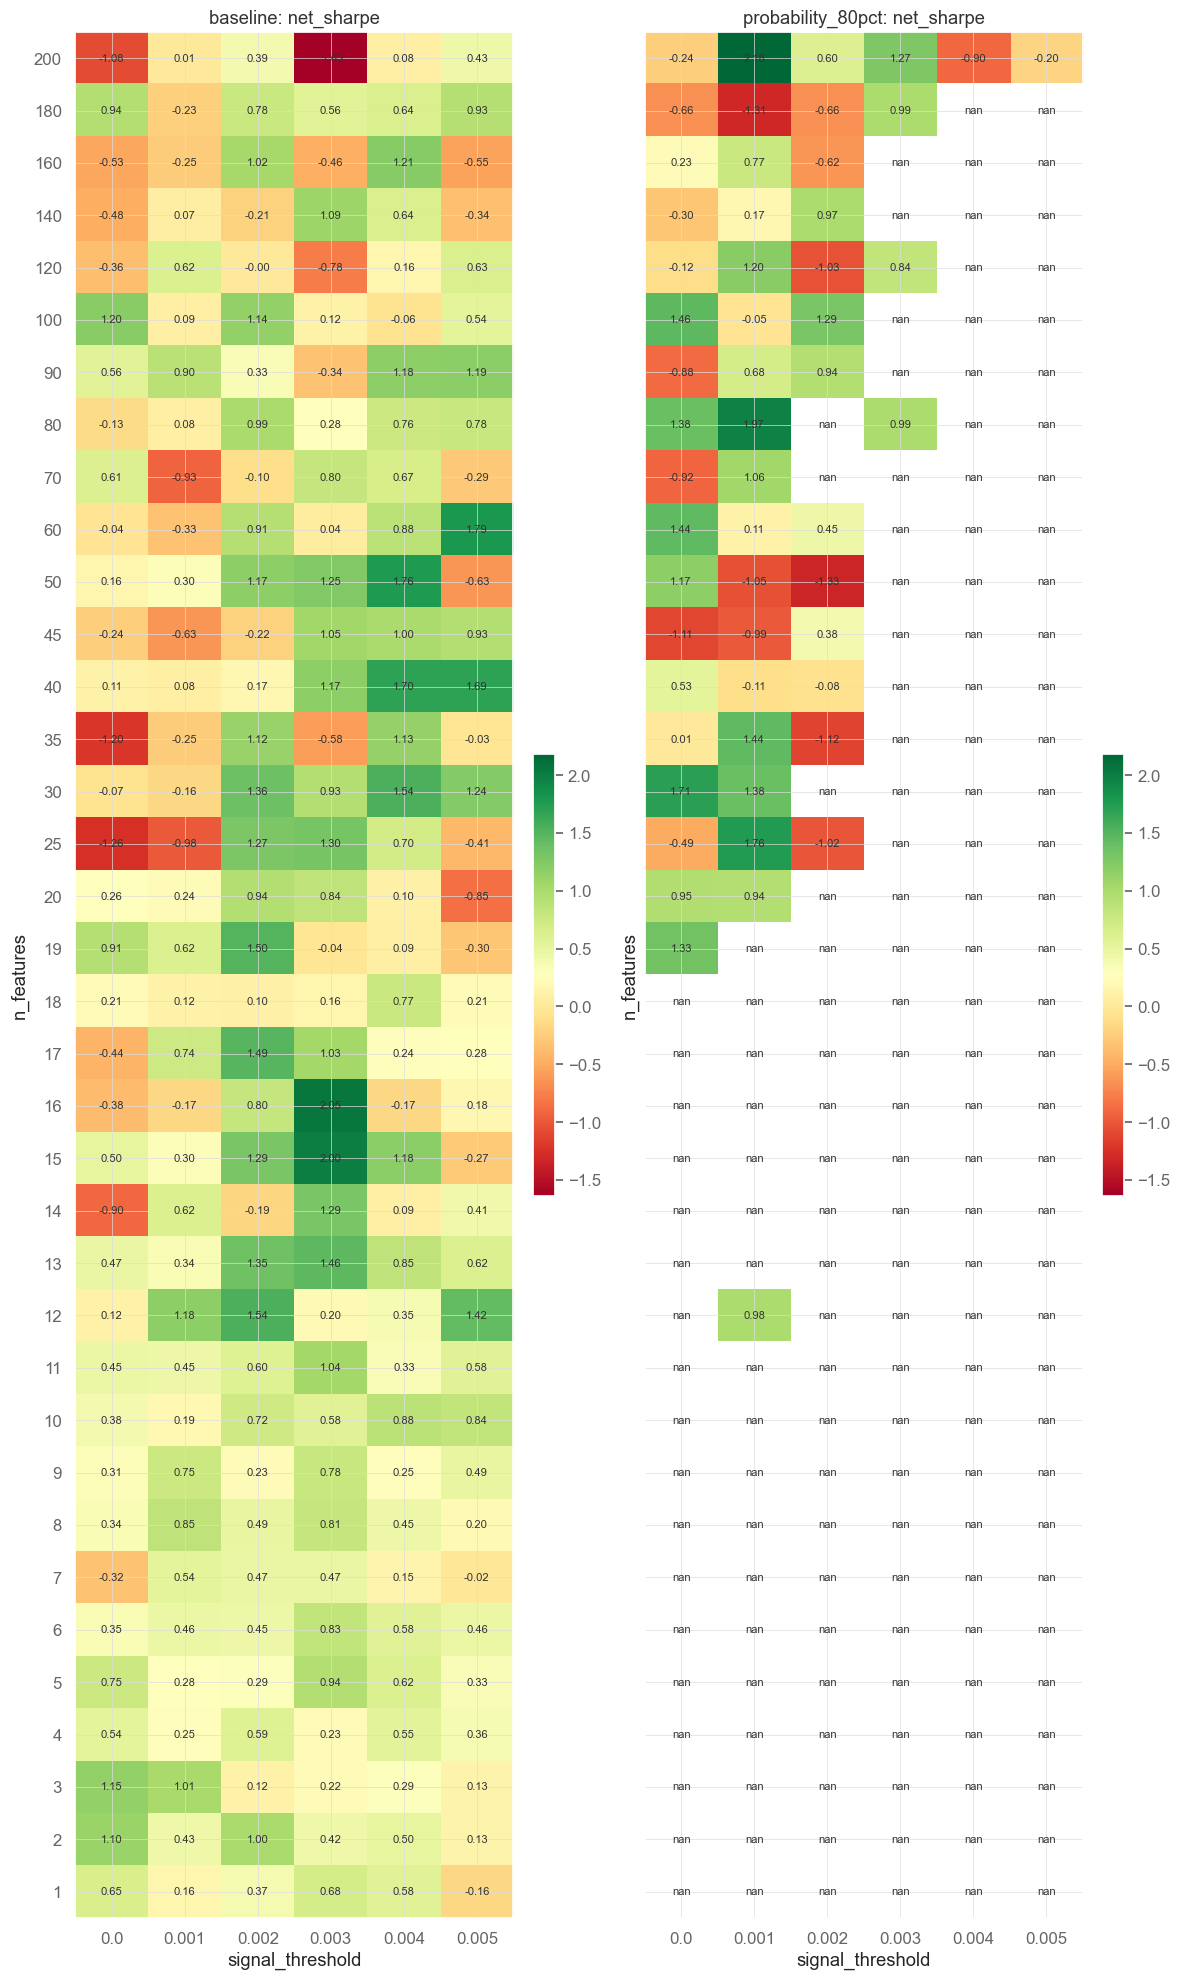

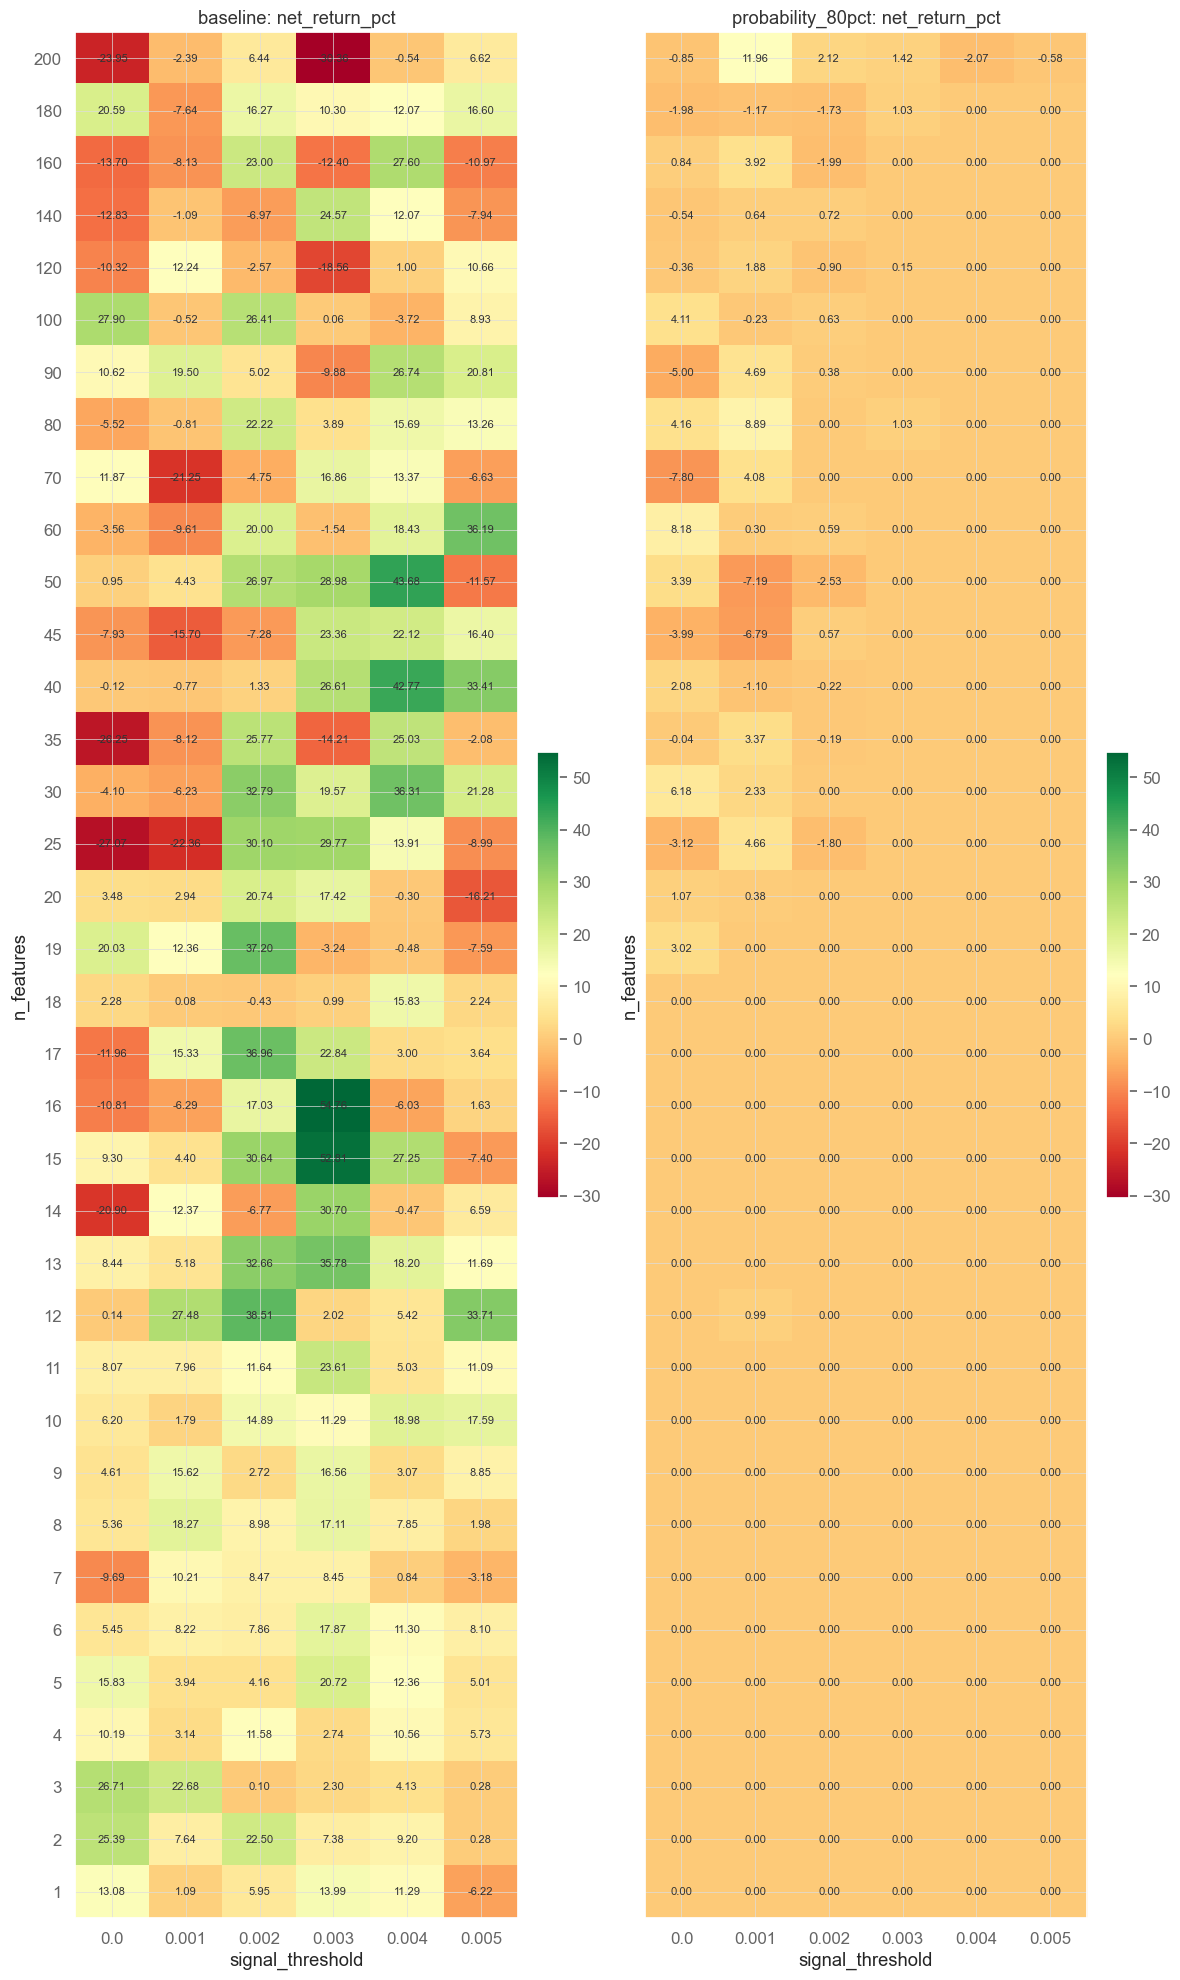

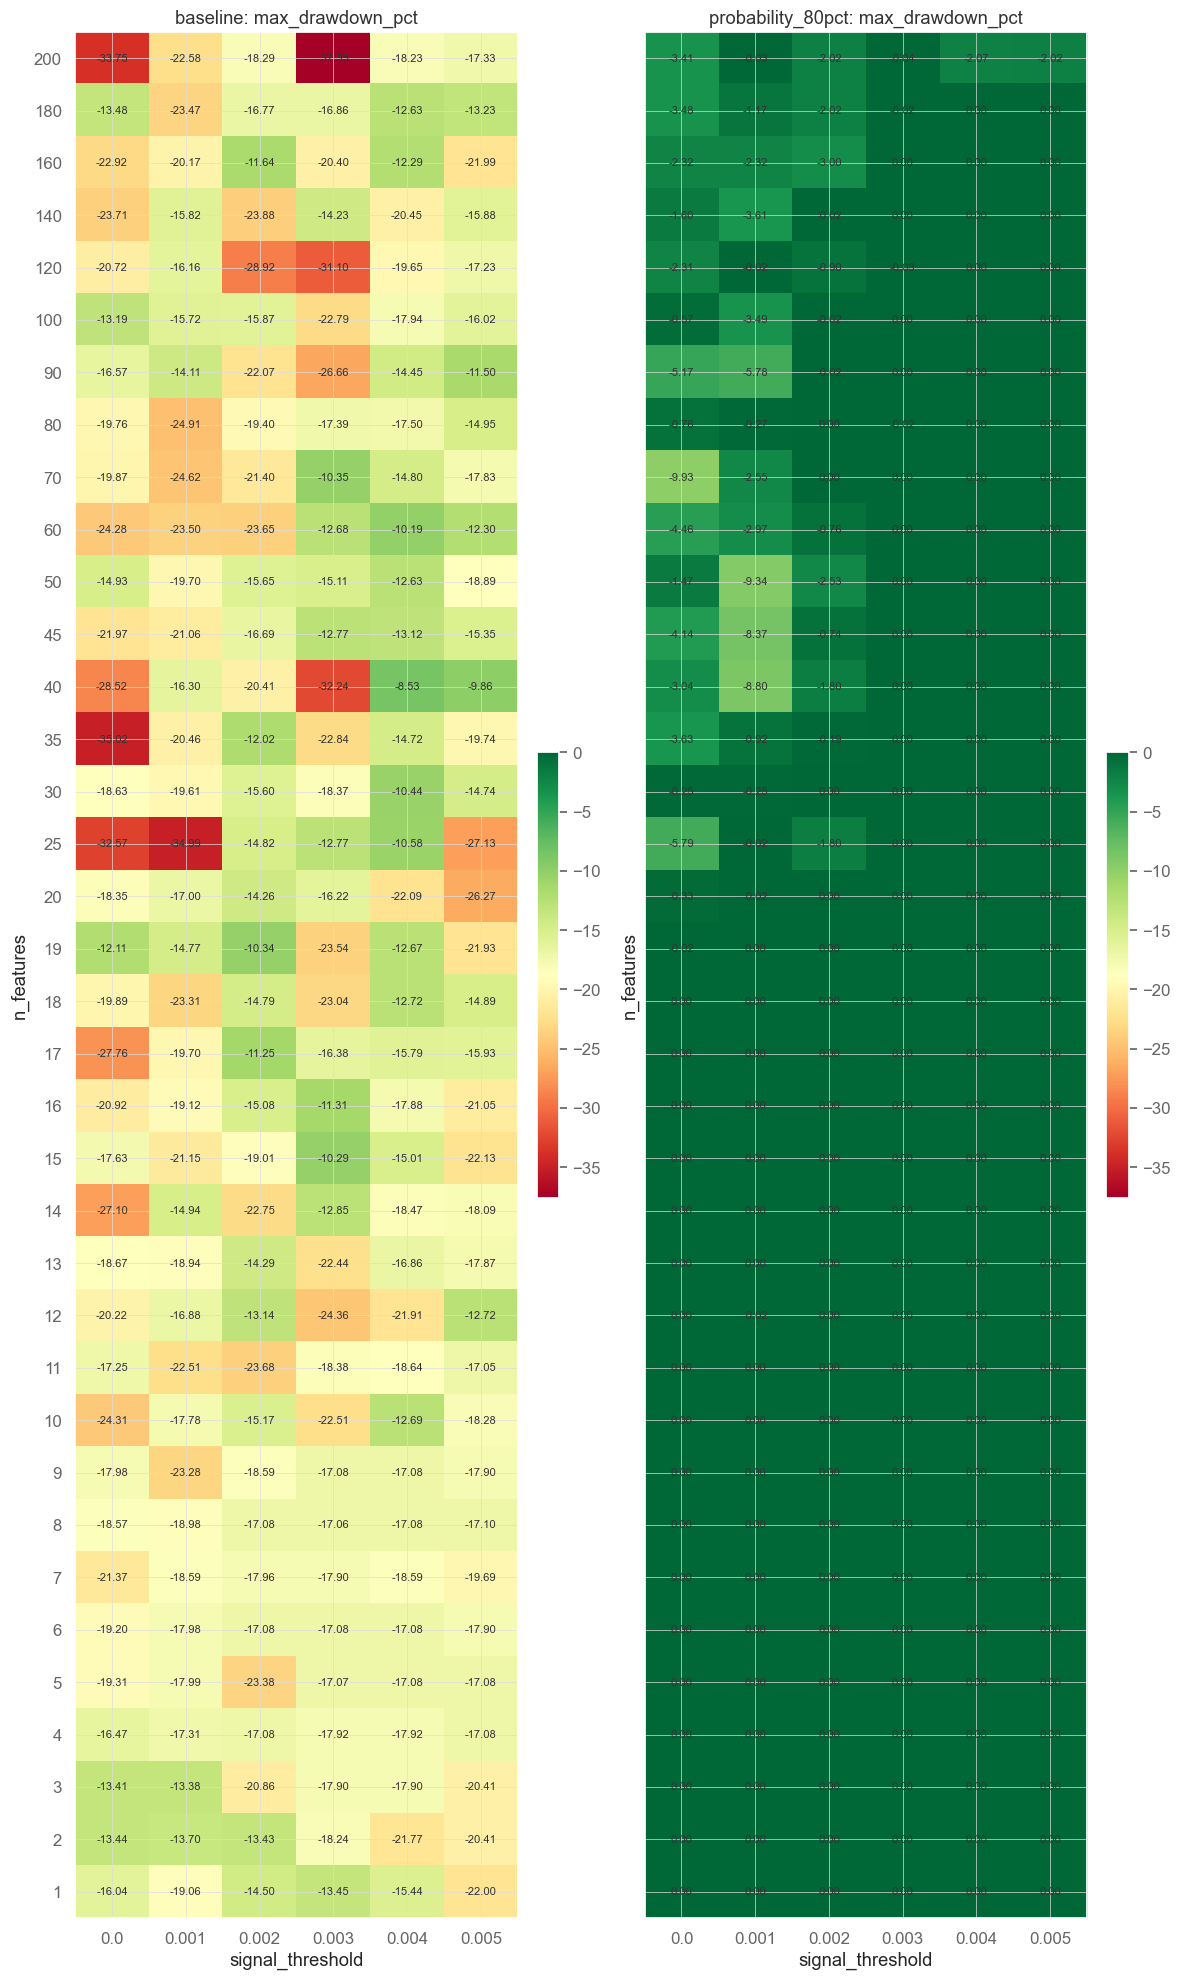

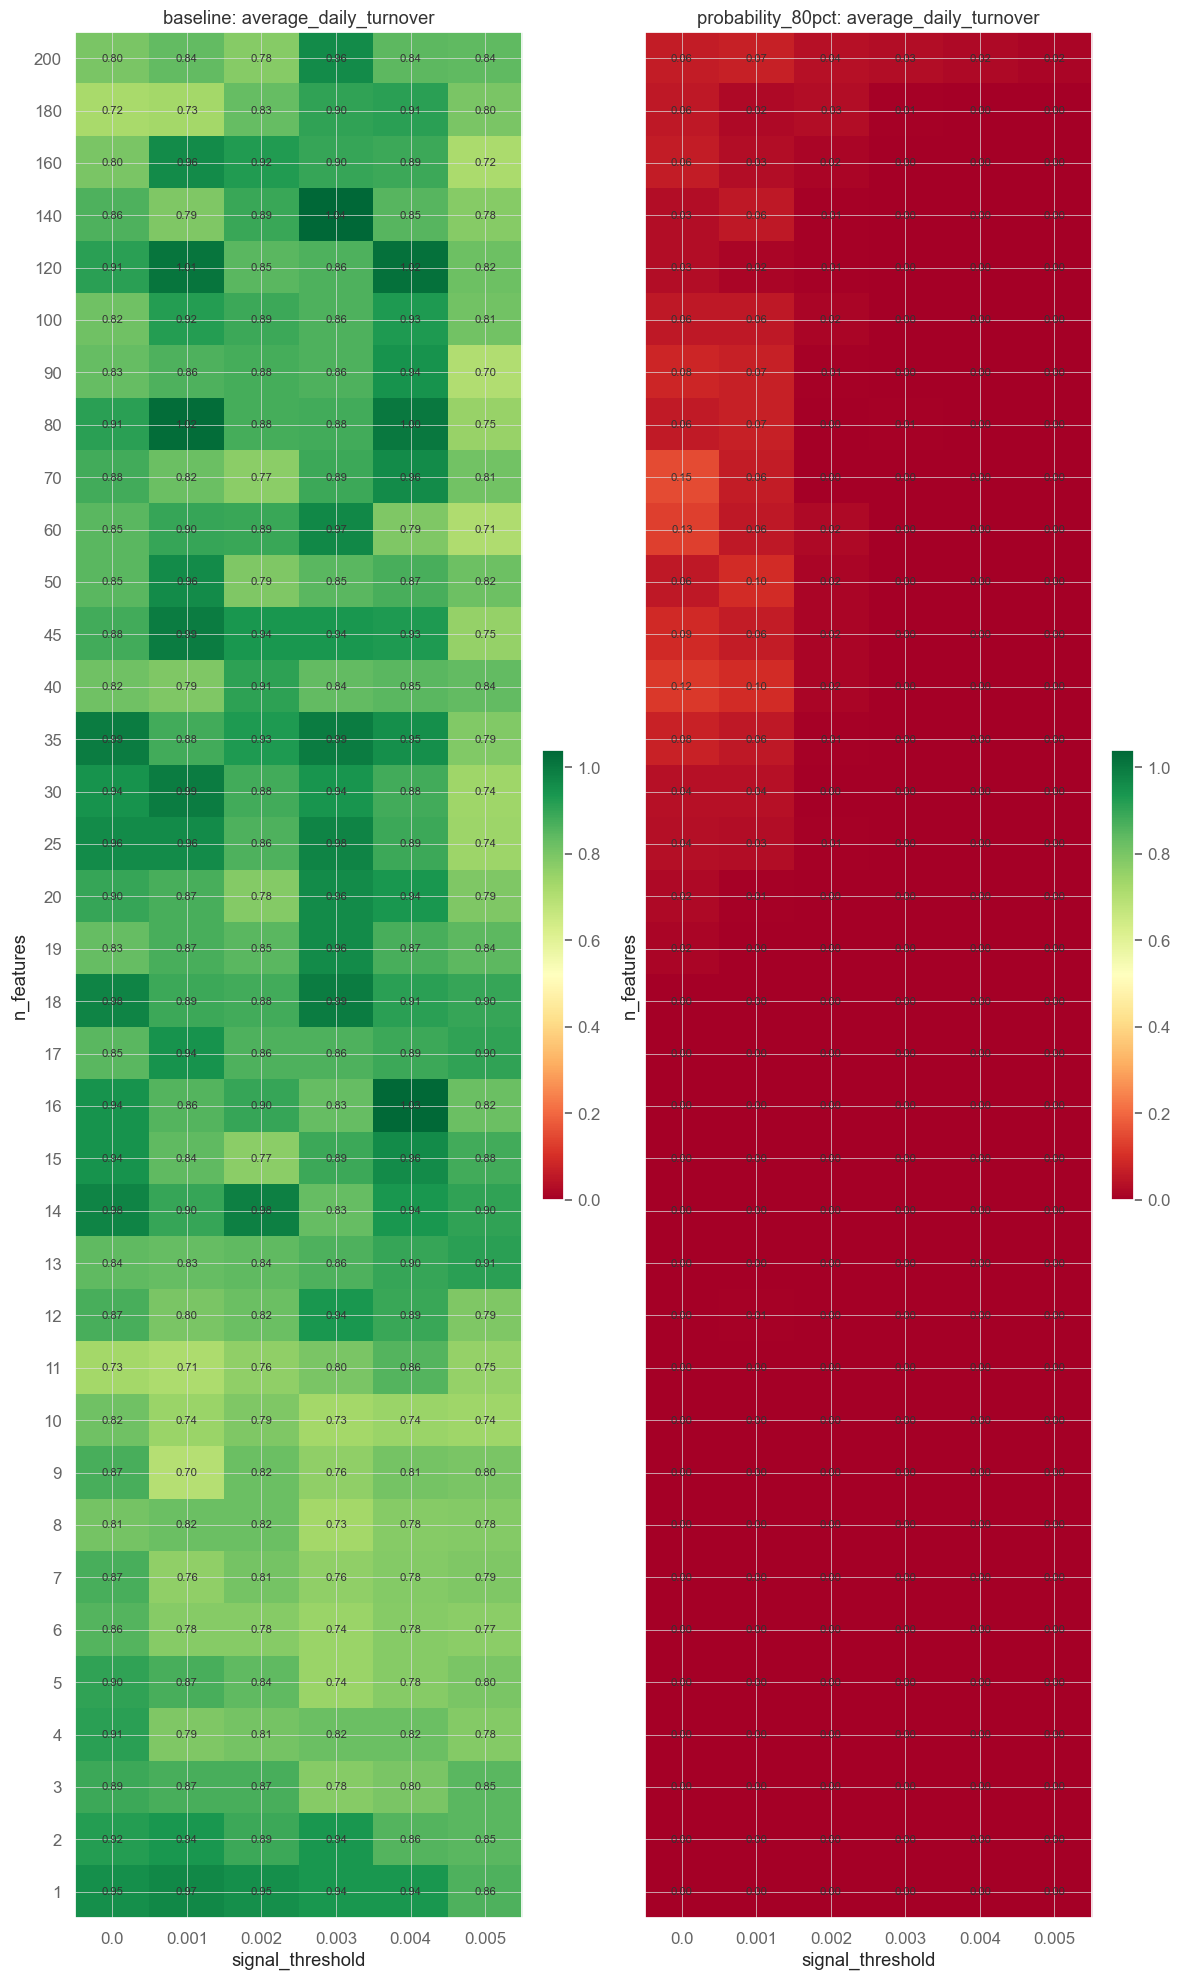

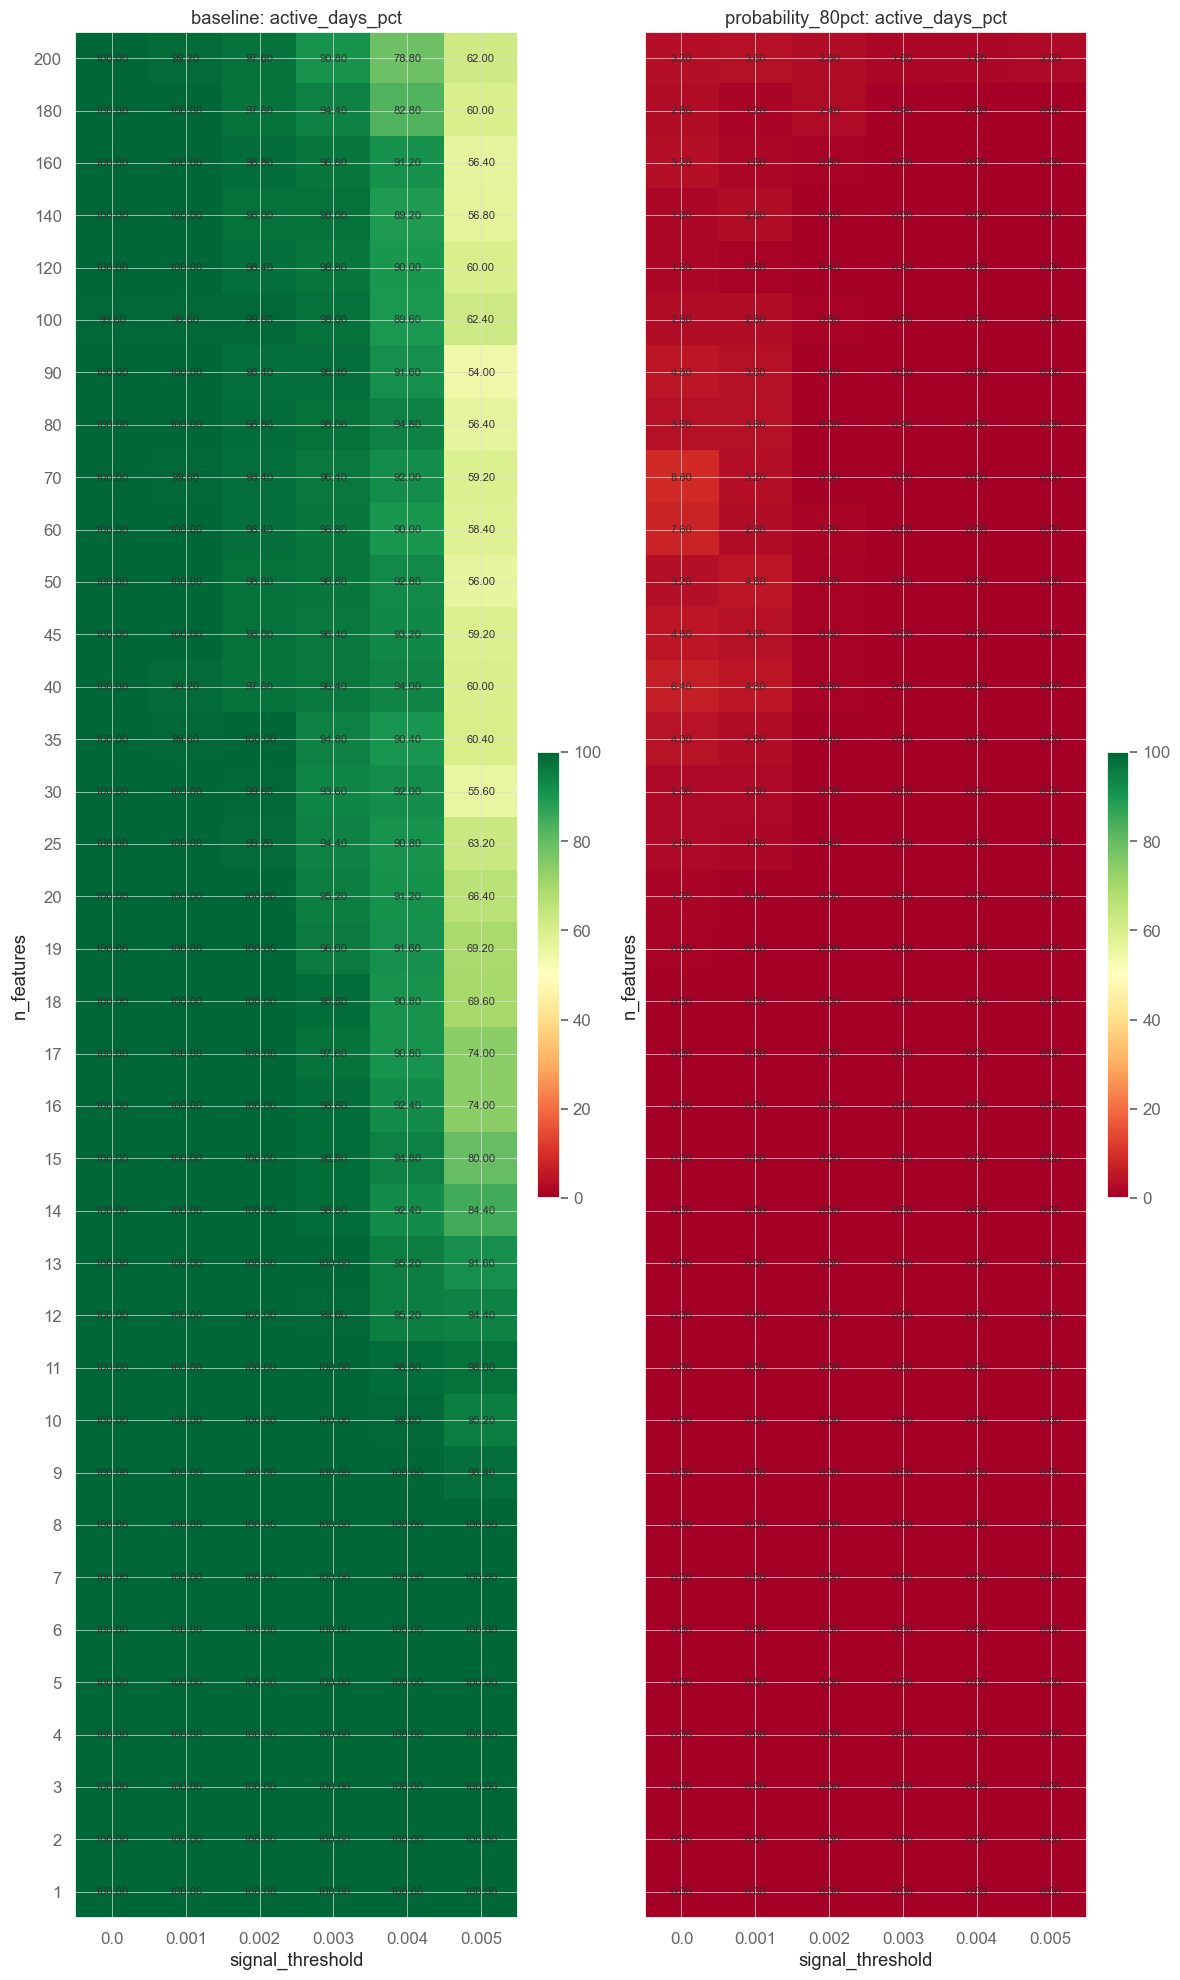

In [15]:
def plot_metric_grid(metric: str):
    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(6 * len(STRATEGIES), 20), sharey=True)
    if len(STRATEGIES) == 1:
        axes = [axes]

    metric_values = metrics_df.loc[metrics_df["strategy"].isin(STRATEGIES), metric]
    shared_vmin, shared_vmax = metric_values.min(), metric_values.max()

    for ax, strategy_name in zip(axes, STRATEGIES):
        pivot = (
            metrics_df[metrics_df["strategy"] == strategy_name]
            .pivot(index="n_features", columns="signal_threshold", values=metric)
            .sort_index(ascending=False)
        )
        image = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=shared_vmin, vmax=shared_vmax)
        ax.set_title(f"{strategy_name}: {metric}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("signal_threshold")
        ax.set_ylabel("n_features")
        for row in range(pivot.shape[0]):
            for column in range(pivot.shape[1]):
                ax.text(column, row, f"{pivot.values[row, column]:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "average_daily_turnover", "active_days_pct"]:
    plot_metric_grid(metric)

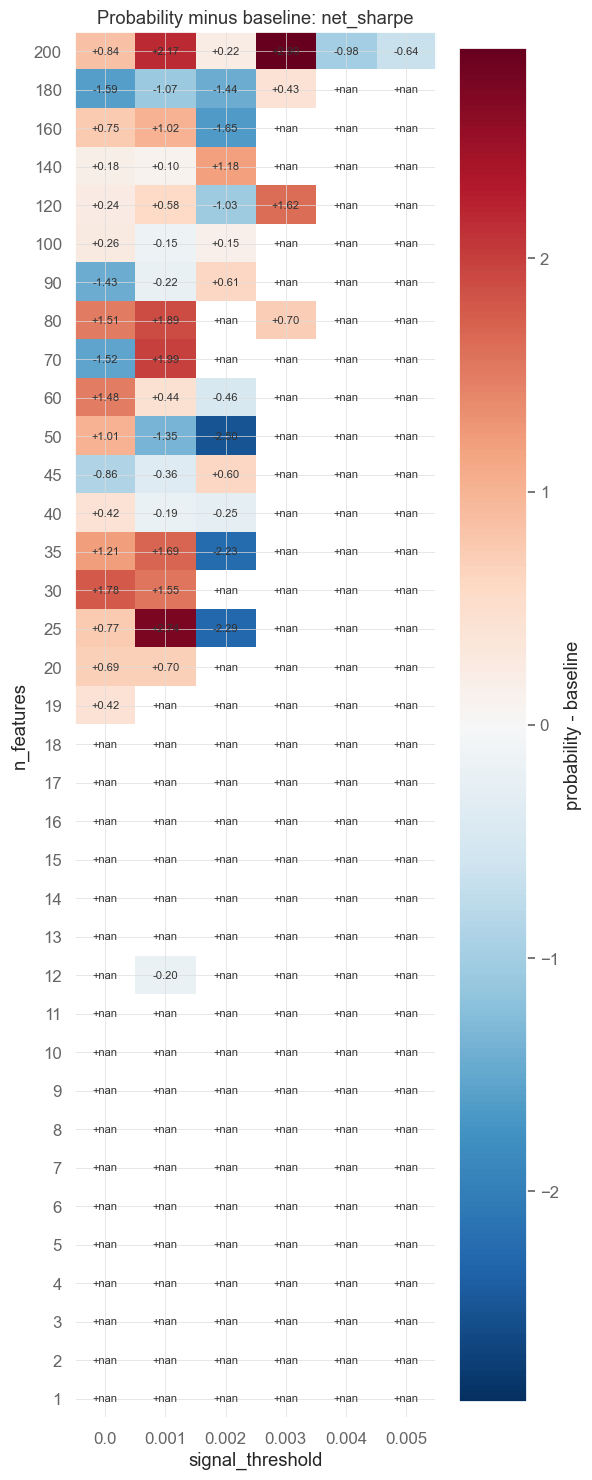

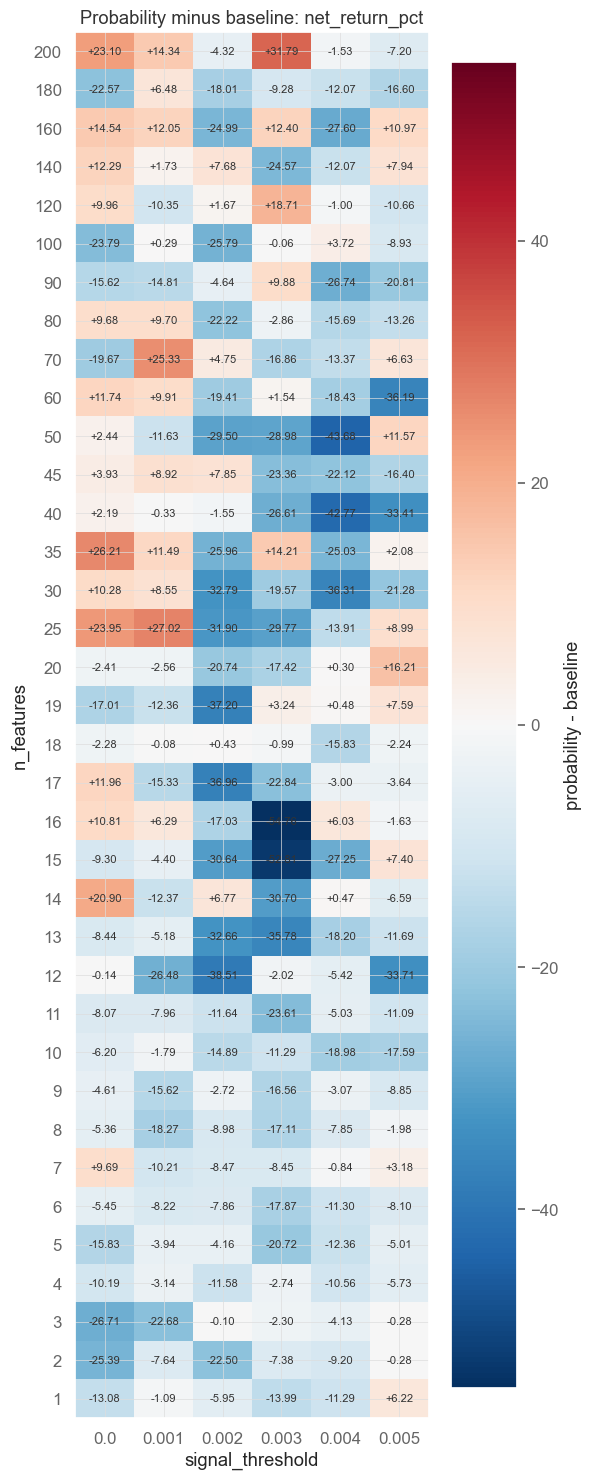

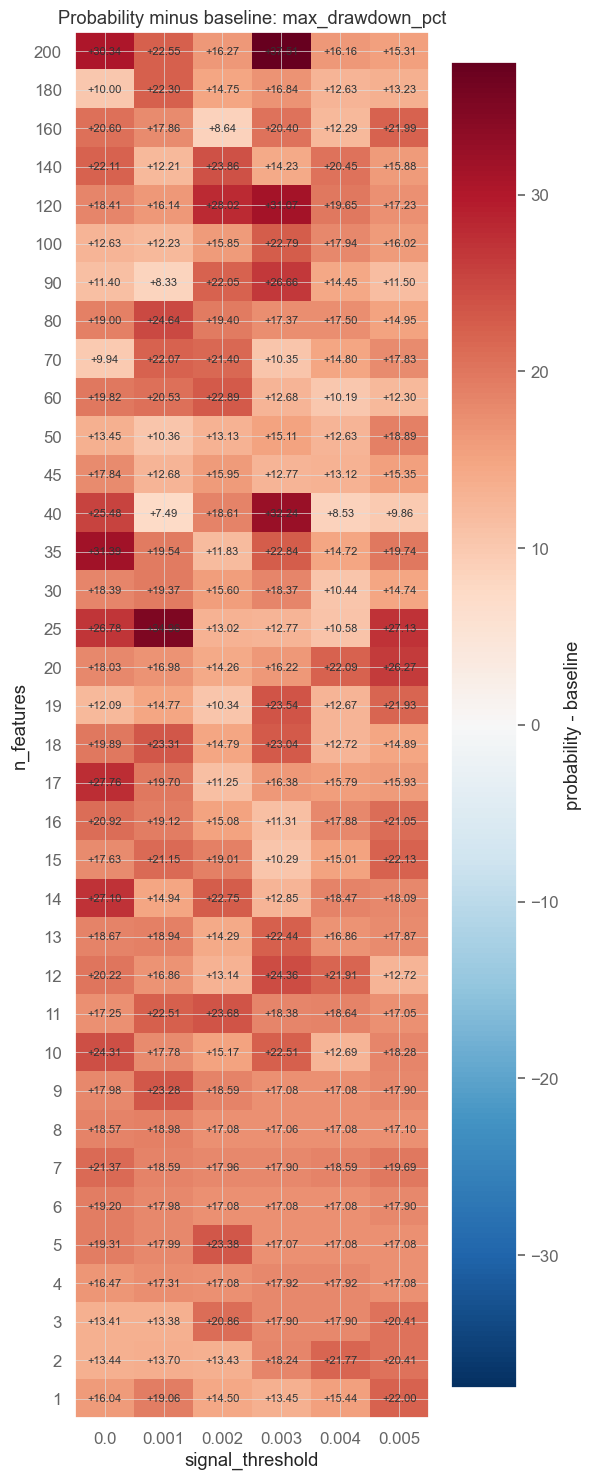

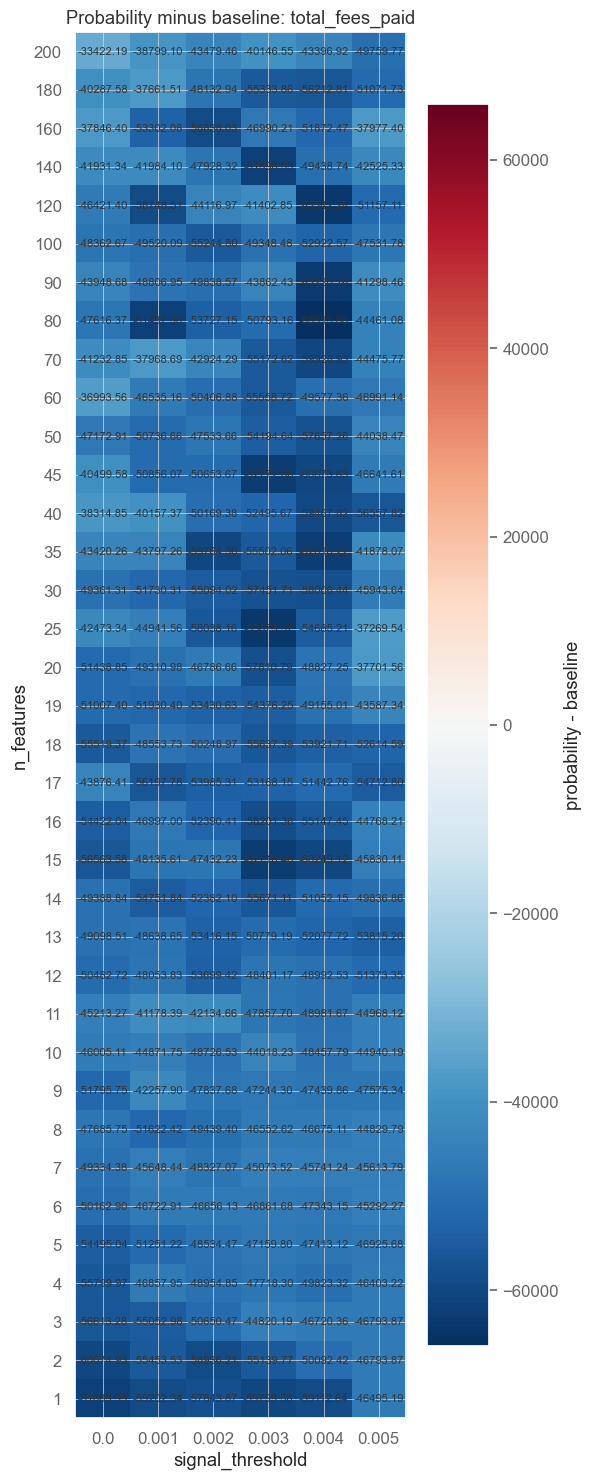

In [18]:
def plot_delta_grid(metric: str):
    pivot = (
        deltas_df[deltas_df["metric"] == metric]
        .pivot(index="n_features", columns="signal_threshold", values="probability_minus_baseline")
        .sort_index(ascending=False)
    )
    bound = np.nanmax(np.abs(pivot.values))
    fig, ax = plt.subplots(figsize=(6, 15))
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
    ax.set_title(f"Probability minus baseline: {metric}")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("signal_threshold")
    ax.set_ylabel("n_features")
    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            ax.text(column, row, f"{pivot.values[row, column]:+.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, label="probability - baseline")
    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "total_fees_paid"]:
    plot_delta_grid(metric)

## 8. Prediction and Executed-Weight Agreement

The raw predicted class should generally agree because both strategies train the same MLP. Executed weights can differ when the probability strategy rejects predictions at or below 80% confidence.

In [10]:
agreement_records = []

for n_features in N_FEATURES_GRID:
    for signal_threshold in SIGNAL_THRESHOLD_GRID:
        baseline_id = make_run_id(SYMBOL, "baseline", n_features, signal_threshold)
        probability_id = make_run_id(SYMBOL, "probability_80pct", n_features, signal_threshold)
        if baseline_id not in grid_artifacts or probability_id not in grid_artifacts:
            continue

        baseline = grid_artifacts[baseline_id]
        probability = grid_artifacts[probability_id]
        raw = pd.concat(
            [
                baseline["predictions"]["prediction"].rename("baseline"),
                probability["predictions"]["prediction"].rename("probability"),
            ],
            axis=1,
        ).dropna()
        executed = pd.concat(
            [
                baseline["weights"][SYMBOL].rename("baseline"),
                probability["weights"][SYMBOL].rename("probability"),
            ],
            axis=1,
        ).dropna()
        confidence = probability["predictions"]["max_probability"]

        agreement_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "raw_class_agreement_pct": (raw["baseline"] == raw["probability"]).mean() * 100,
            "executed_weight_agreement_pct": (executed["baseline"] == executed["probability"]).mean() * 100,
            "directional_weight_agreement_pct": (np.sign(executed["baseline"]) == np.sign(executed["probability"])).mean() * 100,
            "probability_rejection_pct": (confidence <= PROBABILITY_THRESHOLD).mean() * 100,
            "mean_max_probability": confidence.mean(),
            "median_max_probability": confidence.median(),
        })

agreement_df = pd.DataFrame(agreement_records)
display(agreement_df.round(3))
display(agreement_df.describe().round(3))

,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
0,1,0.000,100.0,0.0,0.0,100.0,0.543,0.542
1,1,0.001,100.0,0.0,0.0,100.0,0.515,0.515
2,1,0.002,100.0,0.0,0.0,100.0,0.484,0.483
3,1,0.003,100.0,0.0,0.0,100.0,0.444,0.441
4,1,0.004,100.0,0.0,0.0,100.0,0.411,0.410
...,...,...,...,...,...,...,...,...
211,200,0.001,100.0,4.4,4.4,96.4,0.576,0.549
212,200,0.002,100.0,5.2,5.2,97.2,0.547,0.526
213,200,0.003,100.0,10.8,10.8,98.4,0.493,0.471
214,200,0.004,100.0,22.8,22.8,98.0,0.479,0.449


,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
count,216.000,216.000,216.0,216.000,216.000,216.000,216.000,216.000
mean,45.417,0.002,100.0,6.133,6.133,99.394,0.482,0.472
std,53.480,0.002,0.0,11.382,11.382,1.395,0.068,0.064
min,1.000,0.000,100.0,0.000,0.000,91.200,0.388,0.381
25%,9.750,0.001,100.0,0.000,0.000,99.600,0.413,0.408
50%,18.500,0.002,100.0,1.600,1.600,100.000,0.482,0.470
75%,62.500,0.004,100.0,5.300,5.300,100.000,0.538,0.523
max,200.000,0.005,100.0,46.000,46.000,100.000,0.630,0.611


## 9. Probability Confidence Diagnostics

These plots show how often the 80% cutoff activates and whether higher-confidence grid points correspond to better performance.

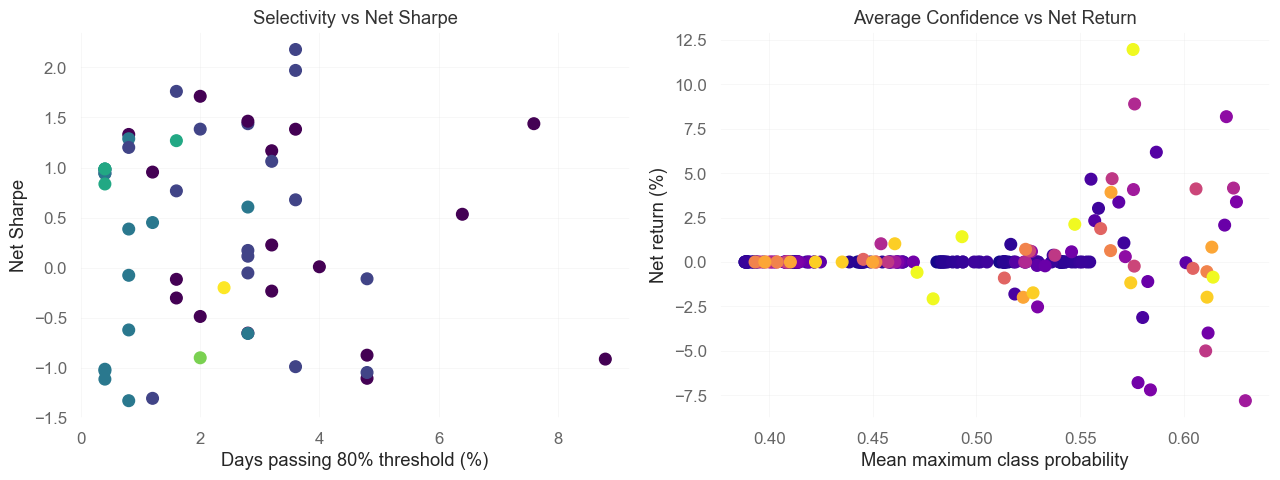

signal_threshold,0.000,0.001,0.002,0.003,0.004,0.005
n_features,,,,,,
200,3.2,3.6,2.8,1.6,2.0,2.4
180,2.8,1.2,2.8,0.4,0.0,0.0
160,3.2,1.6,0.8,0.0,0.0,0.0
140,1.6,2.8,0.4,0.0,0.0,0.0
120,1.6,0.8,0.4,0.4,0.0,0.0
100,2.8,2.8,0.8,0.0,0.0,0.0
90,4.8,3.6,0.4,0.0,0.0,0.0
80,3.6,3.6,0.0,0.4,0.0,0.0
70,8.8,3.2,0.0,0.0,0.0,0.0


In [11]:
probability_metrics = metrics_df[metrics_df["strategy"] == "probability_80pct"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    probability_metrics["passes_probability_threshold_pct"],
    probability_metrics["net_sharpe"],
    c=probability_metrics["signal_threshold"],
    cmap="viridis",
    s=70,
)
axes[0].set_xlabel("Days passing 80% threshold (%)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Selectivity vs Net Sharpe")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    probability_metrics["mean_max_probability"],
    probability_metrics["net_return_pct"],
    c=probability_metrics["n_features"],
    cmap="plasma",
    s=70,
)
axes[1].set_xlabel("Mean maximum class probability")
axes[1].set_ylabel("Net return (%)")
axes[1].set_title("Average Confidence vs Net Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

confidence_grid = probability_metrics.pivot(
    index="n_features",
    columns="signal_threshold",
    values="passes_probability_threshold_pct",
).sort_index(ascending=False)
display(confidence_grid.round(2))

## 10. Equity Curves for Strategy Winners

This compares the best performance-ranked run from each strategy with the equal-weight benchmark used by the vector backtester.

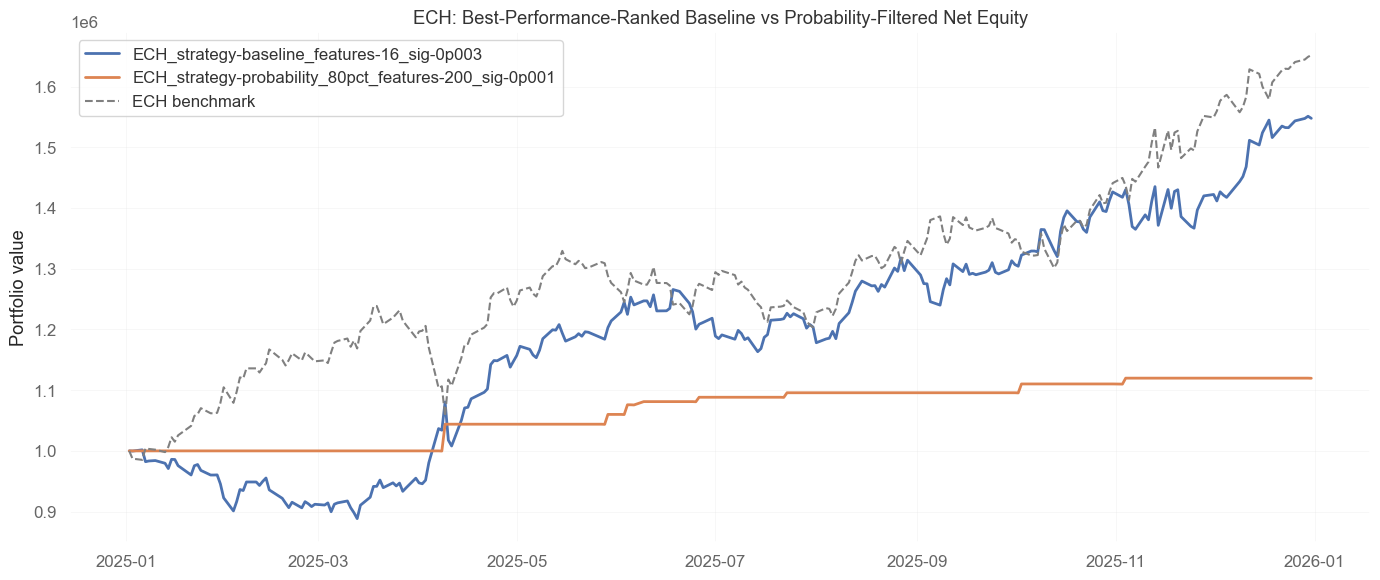

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in best_by_strategy.iterrows():
    run_id = row["run_id"]
    stats = grid_artifacts[run_id]["stats"]
    ax.plot(stats.index, stats["net_equity"], label=run_id, linewidth=2)

benchmark_stats = grid_artifacts[best_by_strategy.iloc[0]["run_id"]]["stats"]
ax.plot(
    benchmark_stats.index,
    INITIAL_CAPITAL * benchmark_stats["cum_benchmark"],
    color="gray",
    linestyle="--",
    label=f"{SYMBOL} benchmark",
)

ax.set_title(f"{SYMBOL}: Best-Performance-Ranked Baseline vs Probability-Filtered Net Equity")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interpretation Checklist

After the grid completes, compare:

- Performance rank as the primary criterion, using the 50% net-return, 25% net-Sharpe, and 25% net-Sortino rank score.
- Matched-grid deltas rather than only each strategy's single best-ranked case.
- Max drawdown, turnover, fees, exposure, and percentage of active days.
- Whether improvements persist across neighboring `n_features` and `signal_threshold` values.
- Raw prediction agreement versus executed-weight agreement.
- How often the probability strategy rejects predictions and whether that selectivity improves risk-adjusted performance.
- Whether the best-ranked result is robust enough to justify testing other probability thresholds in a separate experiment.

In [13]:
from playsound import playsound
playsound()

## 12. Re-run the top two performers from each strategy over additional periods

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Running ECH_strategy-baseline_features-16_sig-0p003_period-2026-01-01-to-2026-07-01
Running ECH_strategy-probability_80pct_features-200_sig-0p001_period-2026-01-01-to-2026-07-01
Running ECH_strategy-baseline_features-15_sig-0p003_period-2026-01-01-to-2026-07-01
Running ECH_strategy-probability_80pct_features-80_sig-0p001_period-2026-01-01-to-2026-07-01


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  2.2min remaining:  2.2min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  6.1min finished


,selection_performance_rank,selection_performance_score,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
2,36,41.00,1,1.00,ECH_strategy-probability_80pct_features-200_si...,probability_80pct,200,0.001,0.8,1.0,1.0,1.0,11.219,12.895,-1.028,12.248,0.875,0.984,-13.611,16761.419,29.508,21.311,49.18,29.268,21.951,48.780,0.512,47.967,1.626,50.407,51.220,0.667,0.795,52.033,363.347
0,1,3.25,2,2.00,ECH_strategy-baseline_features-16_sig-0p003_pe...,baseline,16,0.003,NaN,2.0,2.0,2.0,-3.932,-2.028,-1.028,-2.904,-0.053,-0.097,-33.225,19043.592,46.721,52.459,0.82,65.041,34.959,0.000,1.000,34.959,0.000,65.041,100.000,0.862,NaN,100.000,108.602
3,45,52.75,3,3.25,ECH_strategy-probability_80pct_features-80_sig...,probability_80pct,80,0.001,0.8,3.0,4.0,3.0,-15.155,-14.183,-1.028,-14.127,-1.798,-1.389,-20.678,9719.296,9.016,17.213,73.77,12.195,14.634,73.171,0.268,52.033,1.626,46.341,26.829,0.415,0.700,26.829,289.860
1,2,4.25,4,3.75,ECH_strategy-baseline_features-15_sig-0p003_pe...,baseline,15,0.003,NaN,4.0,3.0,4.0,-27.246,-25.547,-1.028,-26.217,-1.646,-2.497,-47.226,16989.148,46.721,52.459,0.82,65.041,34.959,0.000,1.000,34.959,0.000,65.041,100.000,0.894,NaN,100.000,127.457


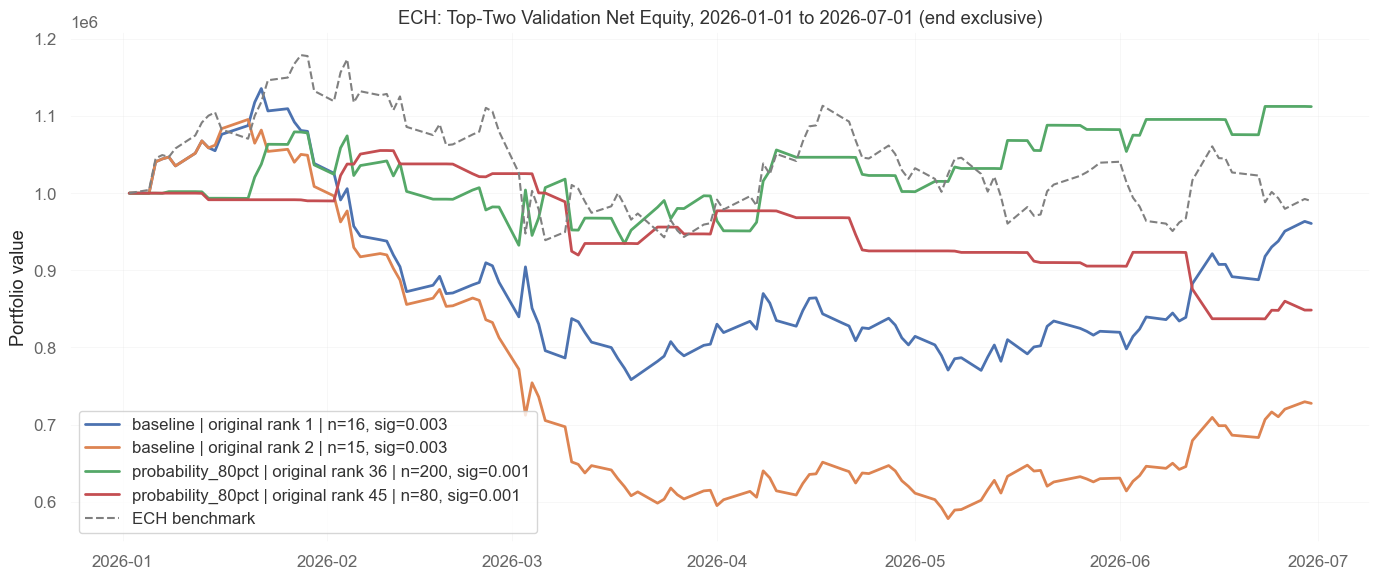

In [22]:
# Re-run the two best original-grid configurations from each strategy on a new period.
def run_validation_case(config: dict, start_date: str, end_date: str) -> dict:
    strategy_name = config["strategy"]
    n_features = int(config["n_features"])
    signal_threshold = float(config["signal_threshold"])
    run_id = f"{make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)}_period-{start_date}-to-{end_date}"
    print(f"Running {run_id}")
    start = time.time()

    params = {
        **COMMON_PARAMS,
        "start_date": start_date,
        "end_date": end_date,
        "n_features": n_features,
        "signal_threshold": signal_threshold,
    }
    if strategy_name == "probability_80pct":
        params["probability_threshold"] = PROBABILITY_THRESHOLD

    strategy = STRATEGIES[strategy_name](params=params)
    dataset = strategy.prepare_dataset()
    prediction_output = strategy.predict(dataset, show_progress=SHOW_PROGRESS)

    if isinstance(prediction_output, pd.Series):
        predictions = prediction_output.rename("prediction").to_frame()
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] *= params["position_size"]
        predictions["max_probability"] = np.nan
        predictions["passes_probability_threshold"] = True
    else:
        predictions = prediction_output.copy()
        probability_columns = ["probability_-1", "probability_0", "probability_1"]
        predictions["max_probability"] = predictions[probability_columns].max(axis=1)
        predictions["passes_probability_threshold"] = predictions["max_probability"] > params["probability_threshold"]
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] = weights[SYMBOL].where(predictions["passes_probability_threshold"], 0)
        weights[SYMBOL] *= params["position_size"]

    prices = dataset[["Open"]].rename(columns={"Open": SYMBOL}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=ASSET_CLASS,
        initial_capital=INITIAL_CAPITAL,
        execution_delay=EXECUTION_DELAY,
    )
    stats = engine.run()
    metrics = summarize_performance(
        run_id, strategy_name, params, stats, weights, predictions, time.time() - start
    )
    metrics["selection_performance_rank"] = int(config["performance_rank"])
    metrics["selection_performance_score"] = float(config["performance_score"])
    artifacts = {
        "run_id": run_id,
        "params": params,
        "weights": weights,
        "predictions": predictions,
        "prices": prices,
        "stats": stats,
        "metrics": metrics,
    }
    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)
    return artifacts


def run_top_two_for_period(start_date: str, end_date: str):
    selected = (
        metrics_df.sort_values(
            ["performance_rank", "performance_score", "net_return_pct"],
            ascending=[True, True, False],
        )
        .groupby("strategy", sort=False)
        .head(2)
    )
    assert selected.groupby("strategy").size().eq(2).all()
    configs = selected.to_dict("records")
    results = Parallel(n_jobs=min(4, len(configs)), backend="loky", verbose=10)(
        delayed(run_validation_case)(config, start_date, end_date)
        for config in configs
    )

    artifacts = {result["run_id"]: result for result in results}
    period_metrics = pd.DataFrame([result["metrics"] for result in results])
    period_metrics["net_return_rank"] = period_metrics["net_return_pct"].rank(method="min", ascending=False, na_option="bottom")
    period_metrics["net_sharpe_rank"] = period_metrics["net_sharpe"].rank(method="min", ascending=False, na_option="bottom")
    period_metrics["net_sortino_rank"] = period_metrics["net_sortino"].rank(method="min", ascending=False, na_option="bottom")
    period_metrics["performance_score"] = (
        0.50 * period_metrics["net_return_rank"]
        + 0.25 * period_metrics["net_sharpe_rank"]
        + 0.25 * period_metrics["net_sortino_rank"]
    )
    period_metrics["performance_rank"] = period_metrics["performance_score"].rank(method="min", ascending=True).astype(int)
    period_metrics = period_metrics.sort_values(
        ["performance_rank", "performance_score", "net_return_pct"],
        ascending=[True, True, False],
    )

    period_display_cols = [
        "selection_performance_rank", "selection_performance_score", *leaderboard_cols,
    ]
    display(period_metrics[period_display_cols].round(3))

    fig, ax = plt.subplots(figsize=(14, 6))
    for result in results:
        result_metrics = result["metrics"]
        label = (
            f"{result_metrics['strategy']} | original rank "
            f"{result_metrics['selection_performance_rank']} | "
            f"n={result_metrics['n_features']}, sig={result_metrics['signal_threshold']:g}"
        )
        ax.plot(result["stats"].index, result["stats"]["net_equity"], label=label, linewidth=2)

    benchmark_stats = results[0]["stats"]
    ax.plot(
        benchmark_stats.index,
        INITIAL_CAPITAL * benchmark_stats["cum_benchmark"],
        color="gray",
        linestyle="--",
        label=f"{SYMBOL} benchmark",
    )
    ax.set_title(f"{SYMBOL}: Top-Two Validation Net Equity, {start_date} to {end_date} (end exclusive)")
    ax.set_ylabel("Portfolio value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if SAVE_ARTIFACTS:
        period_tag = f"{start_date}_to_{end_date}"
        period_metrics.to_pickle(OUTPUT_DIR / f"top_two_{period_tag}_metrics.pkl")
        period_metrics.to_csv(OUTPUT_DIR / f"top_two_{period_tag}_metrics.csv", index=False)

    return period_metrics, artifacts


validation_2026_metrics, validation_2026_artifacts = run_top_two_for_period(
    "2026-01-01", "2026-07-01"
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Running ECH_strategy-baseline_features-16_sig-0p003_period-2019-01-01-to-2026-07-01
Running ECH_strategy-baseline_features-15_sig-0p003_period-2019-01-01-to-2026-07-01
Running ECH_strategy-probability_80pct_features-200_sig-0p001_period-2019-01-01-to-2026-07-01
Running ECH_strategy-probability_80pct_features-80_sig-0p001_period-2019-01-01-to-2026-07-01


[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed: 20.4min
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 20.5min remaining: 20.5min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 79.6min finished


,selection_performance_rank,selection_performance_score,performance_rank,performance_score,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_rank,net_sharpe_rank,net_sortino_rank,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
1,2,4.25,1,1.25,ECH_strategy-baseline_features-15_sig-0p003_pe...,baseline,15,0.003,NaN,1.0,1.0,2.0,240.201,351.504,26.029,214.172,0.651,0.911,-55.692,1113029.546,52.444,45.749,1.807,53.478,45.831,0.690,0.993,45.831,0.690,53.478,99.310,0.870,NaN,100.000,1226.896
0,1,3.25,2,1.75,ECH_strategy-baseline_features-16_sig-0p003_pe...,baseline,16,0.003,NaN,2.0,2.0,1.0,236.831,323.419,26.029,210.802,0.644,0.924,-62.399,865880.195,52.444,46.068,1.488,52.310,47.318,0.372,0.996,47.318,0.372,52.310,99.628,0.854,NaN,100.000,1230.584
2,36,41.00,3,3.00,ECH_strategy-probability_80pct_features-200_si...,probability_80pct,200,0.001,0.8,3.0,3.0,3.0,-2.186,13.419,26.029,-28.215,0.084,0.076,-51.913,156047.932,12.380,12.912,74.708,13.277,12.321,74.403,0.256,50.664,1.168,48.168,25.597,0.388,0.679,25.757,4778.351
3,45,52.75,4,4.00,ECH_strategy-probability_80pct_features-80_sig...,probability_80pct,80,0.001,0.8,4.0,4.0,4.0,-20.401,-0.804,26.029,-46.431,-0.110,-0.084,-45.093,195977.261,9.564,9.352,81.084,9.825,9.453,80.722,0.193,50.611,0.743,48.646,19.278,0.314,0.659,19.278,3942.944


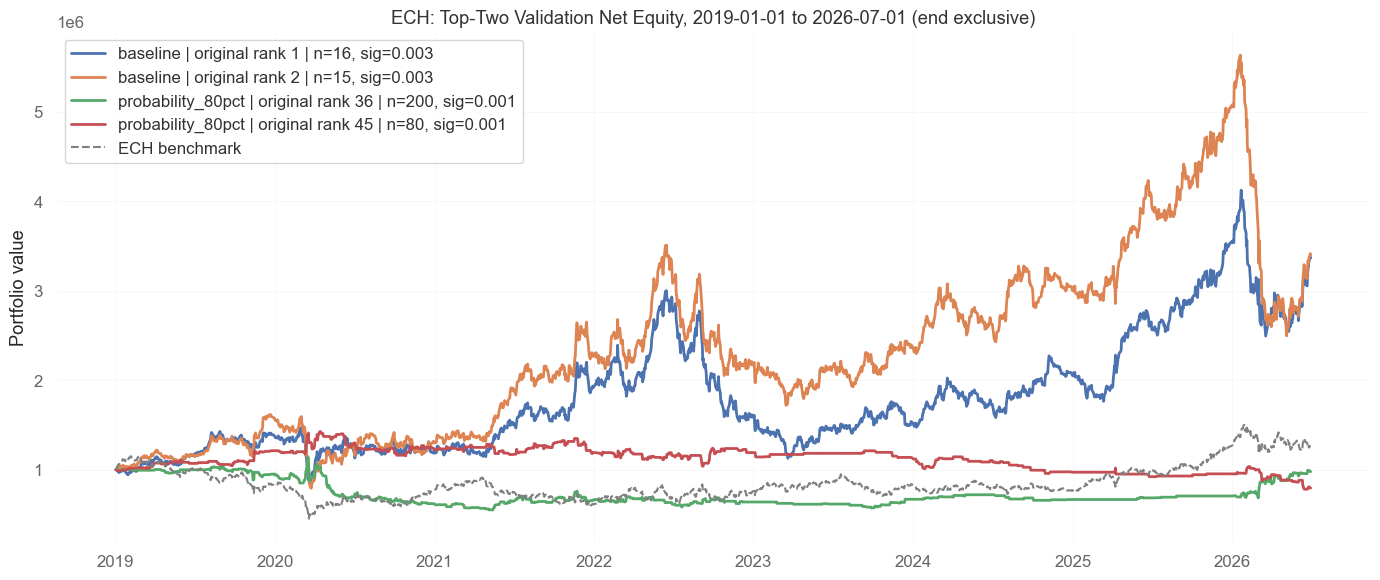

In [23]:
validation_2019_2026_metrics, validation_2019_2026_artifacts = run_top_two_for_period(
    "2019-01-01", "2026-07-01"
)

## 13. Critical Assessment and Conclusion

### Conclusion

The baseline is the better strategy overall under the composite performance objective. It produces substantially higher returns, and its two leading configurations behave similarly over the long historical test.

The 80% probability strategy is better at reducing exposure, fees, and drawdowns, but the filter is too restrictive and does not reliably distinguish good predictions from bad ones. It behaves more like an inconsistent stay-in-cash rule than a consistently superior signal-quality filter.

### Results at a glance

| Period | Baseline | Probability 80% | Verdict |
|---|---:|---:|---|
| Original 2025 grid | Best: **+54.8%**, Sharpe 2.05 | Best: **+12.0%**, Sharpe 2.18 | Baseline |
| 2026 H1 | **−3.9% / −27.2%** | **+11.2% / −15.2%** | Probability n=200, but inconsistent |
| 2019–2026 H1 | **+236.8% / +240.2%** | **−2.2% / −20.4%** | Baseline decisively |
| 2019–2026 benchmark | **+26.0%** | — | Baseline also beats benchmark |

### Why the baseline is better

Its two selected configurations are remarkably consistent over the long test:

- 15 features: +240.2%, Sharpe 0.651, Sortino 0.911.
- 16 features: +236.8%, Sharpe 0.644, Sortino 0.924.

That consistency across adjacent feature counts is encouraging because it suggests that the result is not entirely dependent on one exact hyperparameter choice. The baseline remains invested approximately 99% of the time. Over the long period, its winning days modestly outnumber its losing days—about 52.4% versus 46%—and that small edge compounds substantially.

The equity paths show that the baseline participates in several major profitable regimes, particularly during 2021–2022 and 2024–2025. The probability filter largely misses those advances.

### Why the probability strategy is worse

The 80% cutoff removes too many predictions without reliably selecting better ones. Across the original 216 matched configurations:

- Probability filtering beats the corresponding baseline's net return only **58 times**, about 27%.
- Its median return disadvantage is **−7.86 percentage points**.
- It reduces active days by a median **98.4 percentage points**.
- It improves drawdown in all 216 comparisons.
- It reduces fees by approximately **$49,800 on average**.

The filter clearly controls exposure and costs, but the sacrificed returns generally outweigh those benefits. In the long validation period, the selected probability configurations are active only 19–26% of the time, yet they still experience drawdowns of 45–52%. They therefore accept considerable downside while missing most of the upside.

An 80% class probability measures model confidence, not forecast correctness or expected payoff. The model can be confidently wrong, so the confidence threshold is not consistently identifying profitable opportunities.

### What happened in 2026?

The 200-feature probability configuration genuinely performs best during 2026 H1:

- Net return: +11.2%.
- Sharpe: 0.875.
- Drawdown: −13.6%.
- Active days: 51.2%.

Meanwhile, the baseline configurations lose 3.9% and 27.2%. However, the second probability configuration loses 15.2%. That large difference between the two supposedly best probability configurations weakens the claim that the filter itself caused the improvement. The result appears sensitive to feature count and possibly specific market timing.

The 2026 equity paths show that the winning probability configuration benefits from avoiding much of the baseline's February–March collapse. This demonstrates useful defensive potential, but not yet a stable general advantage.

### Important problem with the performance score

The top original probability run has only 3.6% active days, zero recorded losing gross-return days, and a Sortino ratio of **321.1**. This Sortino is not a credible stable risk estimate: it is enormous because there are almost no downside observations. Nevertheless, the performance score gives Sortino a 25% weight, allowing this sparse strategy to receive the best Sortino rank.

The score can therefore overreward nearly inactive strategies whose Sharpe or Sortino is calculated from too few non-zero observations. A minimum activity or minimum downside-observation requirement would make the ranking more reliable.

### Critical qualification

The 2019–2026 run is a useful historical robustness test, but it is not truly out-of-sample: the configurations were selected using 2025 results, and that year is contained inside the longer period. Only 2026 H1 is genuinely post-selection.

The final judgement is therefore:

- **Best historical return strategy:** baseline.
- **Best defensive mechanism:** probability filtering.
- **Best 2026 configuration:** probability 80%, 200 features.
- **Best-supported strategy overall:** baseline, but with unacceptable drawdowns and weak 2026 performance.
- **Probability 80% verdict:** too restrictive and insufficiently calibrated to replace the baseline in its current form.

Neither strategy is production-ready. The baseline needs risk controls; the probability strategy needs a better-calibrated or lower cutoff and a ranking system that does not reward unstable Sharpe and Sortino values from extremely sparse trading.